In [1]:
import pandas as pd

# Ruta del archivo (ajusta si es necesario)
file_path = "src/Data_Dictionary.xlsx"

# Cargar todas las hojas del excel en un diccionario
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Mostrar el nombre de cada hoja y las primeras filas de cada una
for sheet_name, df in all_sheets.items():
    print(f"\n--- {sheet_name} ---")
    print(df.head())
    print(f"Shape: {df.shape}")



--- train ---
            train.csv                           Unnamed: 1
0                 NaN                                  NaN
1             Columns                          Description
2             card_id               Unique card identifier
3  first_active_month   'YYYY-MM', month of first purchase
4           feature_1  Anonymized card categorical feature
Shape: (8, 2)

--- history ---
  historical_transactions.csv                   Unnamed: 1
0                         NaN                          NaN
1                     Columns                  Description
2                     card_id              Card identifier
3                   month_lag  month lag to reference date
4               purchase_date                Purchase date
Shape: (16, 2)

--- new_merchant_period ---
  new_merchant_period.csv                   Unnamed: 1
0                     NaN                          NaN
1                 Columns                  Description
2                 card_id            

In [16]:
import polars as pl

# Ruta (ajusta si lo tienes en src/)
train_path = "src/train.csv"

# Cargar el dataset
df_train = pl.read_csv(train_path)

# Ver info general
print(df_train.shape)
print(df_train.head(10))
print(df_train.schema)


(201917, 6)
shape: (10, 6)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    │
│ ---                ┆ ---             ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str                ┆ str             ┆ i64       ┆ i64       ┆ i64       ┆ f64       │
╞════════════════════╪═════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2017-06            ┆ C_ID_92a2005557 ┆ 5         ┆ 2         ┆ 1         ┆ -0.820283 │
│ 2017-01            ┆ C_ID_3d0044924f ┆ 4         ┆ 1         ┆ 0         ┆ 0.392913  │
│ 2016-08            ┆ C_ID_d639edf6cd ┆ 2         ┆ 2         ┆ 0         ┆ 0.688056  │
│ 2017-09            ┆ C_ID_186d6a6901 ┆ 4         ┆ 3         ┆ 0         ┆ 0.1424952 │
│ 2017-11            ┆ C_ID_cdbd2c0db2 ┆ 1         ┆ 3         ┆ 0         ┆ -0.159749 │
│ 2016-09            ┆ C_ID_0894217f2f ┆ 4         ┆ 2         ┆ 0         ┆ 0.8715

In [3]:
# Verificar nulos por columna
print(df_train.null_count())

# Ver tipos
print(df_train.dtypes)

shape: (1, 6)
┌────────────────────┬─────────┬───────────┬───────────┬───────────┬────────┐
│ first_active_month ┆ card_id ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target │
│ ---                ┆ ---     ┆ ---       ┆ ---       ┆ ---       ┆ ---    │
│ u32                ┆ u32     ┆ u32       ┆ u32       ┆ u32       ┆ u32    │
╞════════════════════╪═════════╪═══════════╪═══════════╪═══════════╪════════╡
│ 0                  ┆ 0       ┆ 0         ┆ 0         ┆ 0         ┆ 0      │
└────────────────────┴─────────┴───────────┴───────────┴───────────┴────────┘
[String, String, Int64, Int64, Int64, Float64]


shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 201917.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ -0.393636  │
│ std        ┆ 3.8505     │
│ min        ┆ -33.219281 │
│ 25%        ┆ -0.88311   │
│ 50%        ┆ -0.023437  │
│ 75%        ┆ 0.765453   │
│ max        ┆ 17.965068  │
└────────────┴────────────┘


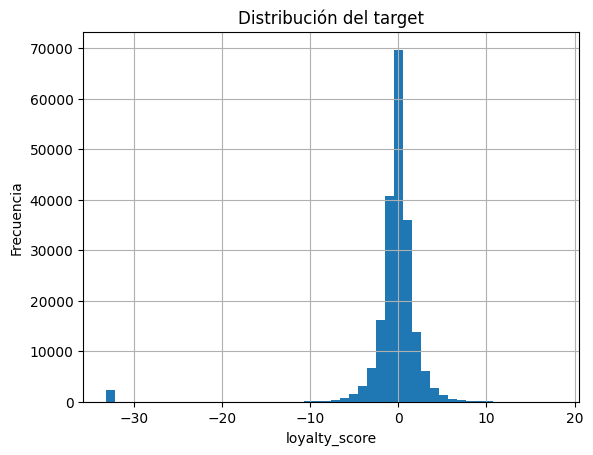

In [4]:
# Estadísticas descriptivas del target (loyalty_score)
print(df_train['target'].describe())

# Histograma del target
import matplotlib.pyplot as plt

df_train['target'].to_pandas().hist(bins=50)
plt.xlabel('loyalty_score')
plt.ylabel('Frecuencia')
plt.title('Distribución del target')
plt.show()

In [5]:
# Revisar valores únicos de las features anonimizadas
for col in ['feature_1', 'feature_2', 'feature_3']:
    print(f"{col}: {df_train[col].unique().to_list()}")

# Revisar formato y valores únicos de la fecha
print(df_train['first_active_month'].unique())


feature_1: [1, 2, 3, 4, 5]
feature_2: [1, 2, 3]
feature_3: [0, 1]
shape: (75,)
Series: 'first_active_month' [str]
[
	"2013-03"
	"2011-12"
	"2012-12"
	"2015-10"
	"2017-02"
	…
	"2012-11"
	"2014-06"
	"2013-11"
	"2018-01"
	"2015-01"
]


Análisis y conclusiones rápidas
1. Dimensiones y nulos
Dataset grande: 201,917 registros y 6 columnas.

Sin nulos en ninguna variable, lo que facilita la modelización y preprocesamiento.

2. Variables
feature_1, feature_2, feature_3: Pocos valores únicos, probablemente variables categóricas codificadas (one-hot o embedding).

first_active_month: Fechas entre "2011-12" y "2018-01" (75 valores únicos, probablemente mensuales).

target (loyalty_score):

Media: -0.39

Desviación estándar: 3.85

Valores extremos: Min -33.2, Max 17.96

Distribución muy sesgada: Gran mayoría cerca de 0, pero hay un grupo pequeño con valores extremadamente bajos (probable outlier/falla en el proceso de datos).

3. Visualización
La gráfica confirma que hay outliers muy negativos (quizás tarjetas bloqueadas, fraudes, o errores).

La mayoría de los scores están entre -5 y 5, pero ese “cluster” de valores negativos debe ser tratado con cuidado (análisis posterior de outliers).

Recomendaciones inmediatas y siguientes pasos

A) Ingeniería de features inicial
Convertir first_active_month a variables numéricas:

Año (year)

Mes (month)

Diferencia en meses respecto al último registro (antigüedad de la tarjeta)

Análisis de outliers en el target: ¿quieres tratarlos (recorte, winsorización) o solo identificarlos por ahora?

B) Cruce posterior

Las features actuales no parecen tener fuga de información.

Para el modelado final, deberemos unir features agregadas por card_id desde los datasets transaccionales, pero aún no.

In [17]:
import polars as pl
import datetime

# Convertir a datetime
df_train = df_train.with_columns(
    pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m")
)

# Extraer año y mes como columnas
df_train = df_train.with_columns([
    pl.col("first_active_month").dt.year().alias("year"),
    pl.col("first_active_month").dt.month().alias("month")
])

# Calcular la antigüedad de la tarjeta (en meses)
# Tomar la fecha máxima del dataset como referencia
max_date = df_train['first_active_month'].max()
df_train = df_train.with_columns(
    ((pl.lit(max_date) - pl.col("first_active_month")) / pl.duration(days=30)).alias("months_active")
)

# Ver resultado
print(df_train.select(["first_active_month", "year", "month", "months_active"]).head(10))

shape: (10, 4)
┌────────────────────┬──────┬───────┬───────────────┐
│ first_active_month ┆ year ┆ month ┆ months_active │
│ ---                ┆ ---  ┆ ---   ┆ ---           │
│ date               ┆ i32  ┆ i8    ┆ f64           │
╞════════════════════╪══════╪═══════╪═══════════════╡
│ 2017-06-01         ┆ 2017 ┆ 6     ┆ 8.166667      │
│ 2017-01-01         ┆ 2017 ┆ 1     ┆ 13.2          │
│ 2016-08-01         ┆ 2016 ┆ 8     ┆ 18.3          │
│ 2017-09-01         ┆ 2017 ┆ 9     ┆ 5.1           │
│ 2017-11-01         ┆ 2017 ┆ 11    ┆ 3.066667      │
│ 2016-09-01         ┆ 2016 ┆ 9     ┆ 17.266667     │
│ 2016-12-01         ┆ 2016 ┆ 12    ┆ 14.233333     │
│ 2017-09-01         ┆ 2017 ┆ 9     ┆ 5.1           │
│ 2017-08-01         ┆ 2017 ┆ 8     ┆ 6.133333      │
│ 2016-08-01         ┆ 2016 ┆ 8     ┆ 18.3          │
└────────────────────┴──────┴───────┴───────────────┘


In [18]:
# ¿Cuántos outliers extremos hay?
outlier_threshold = -20  # Por ejemplo, menos de -20 parece un outlier fuerte

n_outliers = df_train.filter(pl.col('target') < outlier_threshold).height
total = df_train.height
print(f"Outliers target < {outlier_threshold}: {n_outliers} de {total} ({n_outliers/total:.2%})")

# Mostrar algunos ejemplos
print(df_train.filter(pl.col('target') < outlier_threshold).select(['card_id', 'target', 'months_active']))


Outliers target < -20: 2207 de 201917 (1.09%)
shape: (2_207, 3)
┌─────────────────┬────────────┬───────────────┐
│ card_id         ┆ target     ┆ months_active │
│ ---             ┆ ---        ┆ ---           │
│ str             ┆ f64        ┆ f64           │
╞═════════════════╪════════════╪═══════════════╡
│ C_ID_8186f3fcc1 ┆ -33.219281 ┆ 5.1           │
│ C_ID_b9379a30ea ┆ -33.219281 ┆ 33.566667     │
│ C_ID_e9120f535c ┆ -33.219281 ┆ 28.466667     │
│ C_ID_65715cb80d ┆ -33.219281 ┆ 11.233333     │
│ C_ID_ae77d244b6 ┆ -33.219281 ┆ 13.2          │
│ C_ID_c4262c902e ┆ -33.219281 ┆ 31.533333     │
│ C_ID_6a2c823e5f ┆ -33.219281 ┆ 11.233333     │
│ C_ID_98e1cb10b6 ┆ -33.219281 ┆ 8.166667      │
│ C_ID_eb8175721a ┆ -33.219281 ┆ 11.233333     │
│ C_ID_a2580006bf ┆ -33.219281 ┆ 22.366667     │
│ C_ID_2e49ece8b1 ┆ -33.219281 ┆ 14.233333     │
│ C_ID_7efe2311b7 ┆ -33.219281 ┆ 22.366667     │
│ C_ID_bae3e3f87c ┆ -33.219281 ┆ 26.433333     │
│ C_ID_e1844c986c ┆ -33.219281 ┆ 13.2          │
│ C_I

<Axes: title={'center': 'Score medio vs. antigüedad'}, xlabel='months_active'>

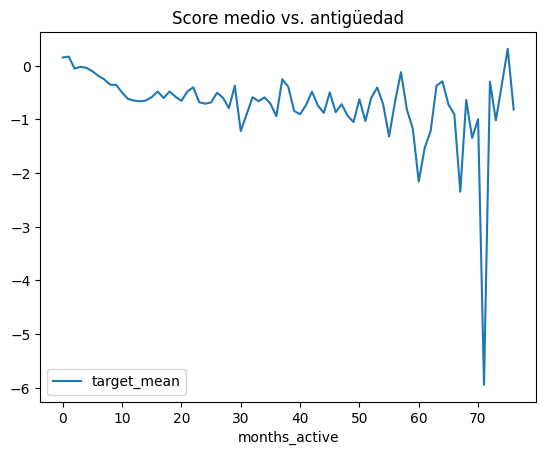

In [19]:
# Agrupa por antigüedad redondeada
df_train.with_columns(
    pl.col('months_active').round(0)
).group_by('months_active').agg(
    [pl.col('target').mean().alias('target_mean')]
).sort('months_active').to_pandas().plot(x='months_active', y='target_mean', kind='line', title="Score medio vs. antigüedad")


In [20]:
for col in ['feature_1', 'feature_2', 'feature_3']:
    print(f"\nPromedio de target por {col}:")
    print(
        df_train.group_by(col).agg(
            pl.col('target').mean().alias('target_mean'),
            pl.col('target').count().alias('count')
        ).sort(col)
    )



Promedio de target por feature_1:
shape: (5, 3)
┌───────────┬─────────────┬───────┐
│ feature_1 ┆ target_mean ┆ count │
│ ---       ┆ ---         ┆ ---   │
│ i64       ┆ f64         ┆ u32   │
╞═══════════╪═════════════╪═══════╡
│ 1         ┆ -0.315476   ┆ 12037 │
│ 2         ┆ -0.350452   ┆ 55797 │
│ 3         ┆ -0.377533   ┆ 73573 │
│ 4         ┆ -0.404652   ┆ 19885 │
│ 5         ┆ -0.499879   ┆ 40625 │
└───────────┴─────────────┴───────┘

Promedio de target por feature_2:
shape: (3, 3)
┌───────────┬─────────────┬───────┐
│ feature_2 ┆ target_mean ┆ count │
│ ---       ┆ ---         ┆ ---   │
│ i64       ┆ f64         ┆ u32   │
╞═══════════╪═════════════╪═══════╡
│ 1         ┆ -0.398675   ┆ 89242 │
│ 2         ┆ -0.332899   ┆ 74839 │
│ 3         ┆ -0.501889   ┆ 37836 │
└───────────┴─────────────┴───────┘

Promedio de target por feature_3:
shape: (2, 3)
┌───────────┬─────────────┬────────┐
│ feature_3 ┆ target_mean ┆ count  │
│ ---       ┆ ---         ┆ ---    │
│ i64       ┆ f64     

In [13]:
df_train.write_parquet("src/train_processed.parquet")

In [26]:
import numpy as np

# Nota: Para remover los outliers imputados (target ≈ -33.219281), 
# usamos tolerancia por precisión numérica.
tolerance = 1e-6
outlier_value = -33.219281

df_train_clean = df_train.filter(
    (pl.col('target') < outlier_value - tolerance) | (pl.col('target') > outlier_value + tolerance)
)
print(f"Shape sin outliers: {df_train_clean.shape}")

Shape sin outliers: (199710, 9)


In [27]:
df_train_clean.write_parquet("src/train_processed_clean.parquet")

In [9]:
import polars as pl

# Ajusta el número máximo de filas y columnas a mostrar
pl.Config.set_tbl_rows(50)      # Cambia el 20 por lo que necesites
pl.Config.set_tbl_cols(200)
pl.Config.set_tbl_width_chars(1000)  # Ancho de la tabla (en caracteres)


polars.config.Config

In [2]:
import polars as pl

hist_path = "src/historical_transactions.csv"

# Leer primeras 100,000 filas para exploración (puedes ajustar el número si tu RAM lo permite)
df_hist = pl.read_csv(hist_path, n_rows=100_000)

print(df_hist.shape)
print(df_hist.head())
print(df_hist.schema)

# Analizar nulos
print(df_hist.null_count())

# ¿Cuántas compras por tarjeta en la muestra?
print(df_hist['card_id'].value_counts().head(10))


(100000, 14)
shape: (5, 14)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ aut ┆ car ┆ cit ┆ cat ┆ ins ┆ cat ┆ mer ┆ mercha ┆ month ┆ purch ┆ purch ┆ categ ┆ state ┆ subse │
│ hor ┆ d_i ┆ y_i ┆ ego ┆ tal ┆ ego ┆ cha ┆ nt_id  ┆ _lag  ┆ ase_a ┆ ase_d ┆ ory_2 ┆ _id   ┆ ctor_ │
│ ize ┆ d   ┆ d   ┆ ry_ ┆ lme ┆ ry_ ┆ nt_ ┆ ---    ┆ ---   ┆ mount ┆ ate   ┆ ---   ┆ ---   ┆ id    │
│ d_f ┆ --- ┆ --- ┆ 1   ┆ nts ┆ 3   ┆ cat ┆ str    ┆ i64   ┆ ---   ┆ ---   ┆ f64   ┆ i64   ┆ ---   │
│ lag ┆ str ┆ i64 ┆ --- ┆ --- ┆ --- ┆ ego ┆        ┆       ┆ f64   ┆ str   ┆       ┆       ┆ i64   │
│ --- ┆     ┆     ┆ str ┆ i64 ┆ str ┆ ry_ ┆        ┆       ┆       ┆       ┆       ┆       ┆       │
│ str ┆     ┆     ┆     ┆     ┆     ┆ id  ┆        ┆       ┆       ┆       ┆       ┆       ┆       │
│     ┆     ┆     ┆     ┆     ┆     ┆ --- ┆        ┆       ┆       ┆       ┆       ┆       ┆       │
│     ┆     ┆     ┆     ┆     ┆     ┆ i64 ┆        ┆       ┆   

Hallazgos Clave
1. Variables con nulos relevantes
category_3: 336 nulos

merchant_id: 472 nulos

category_2: 7,631 nulos
Estas columnas requerirán imputación (modo/categoría más frecuente, -1 o similar) o un tratamiento especial.

2. Volumen de transacciones
Hay tarjetas con muy pocas compras y otras con más de 400 en la muestra.

Esto justifica la agregación por card_id para reducir la granularidad y evitar overfitting en clientes con muchos datos.

3. Estructura de datos
Fechas en string, será útil transformarlas.

Variables numéricas (montos, cuotas, etc.) y categóricas.

Siguiente paso: Feature Engineering y Agregaciones
El objetivo es generar features agregadas por card_id para sumar al dataset principal (train/test).
Esto es vital para que el modelo trabaje a nivel tarjeta y no transacción.

A) Plan de features agregadas
Para cada card_id:

Features numéricas:

Suma, media, mediana, std, máximo, mínimo de purchase_amount, installments

Cantidad de compras

Features categóricas:

Modo y número de categorías distintas de category_1, category_2, category_3

Número de comercios distintos (merchant_id)

Número de meses distintos (month_lag)

Fecha de última y primera compra (convertidas a duración)

In [7]:
import polars as pl

# Si tienes RAM limitada, puedes hacer esto por partes o usar scan_csv

hist_path = "src/historical_transactions.csv"
# Usar scan_csv para trabajar en lazy mode (Polars es eficiente con esto)
df_hist = pl.scan_csv(hist_path)

# Transformar fechas a Date
df_hist = df_hist.with_columns([
    pl.col("purchase_date").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("purchase_date_dt")
])

# Imputar nulos simples
df_hist = df_hist.with_columns([
    pl.col("category_3").fill_null("A"),  # Modo
    pl.col("category_2").fill_null(-1),
    pl.col("merchant_id").fill_null("unknown")
])

# Features agregadas
features_agg = df_hist.group_by("card_id").agg([
    # Numéricas
    pl.col("purchase_amount").mean().alias("hist_purchase_mean"),
    pl.col("purchase_amount").std().alias("hist_purchase_std"),
    pl.col("purchase_amount").min().alias("hist_purchase_min"),
    pl.col("purchase_amount").max().alias("hist_purchase_max"),
    pl.col("installments").mean().alias("hist_installments_mean"),
    pl.col("installments").std().alias("hist_installments_std"),
    pl.col("installments").min().alias("hist_installments_min"),
    pl.col("installments").max().alias("hist_installments_max"),
    pl.count().alias("hist_num_transactions"),

    # Fechas
    pl.col("purchase_date_dt").min().alias("hist_first_purchase"),
    pl.col("purchase_date_dt").max().alias("hist_last_purchase"),

    # Categóricas
    pl.col("merchant_id").n_unique().alias("hist_uniq_merchants"),
    pl.col("category_1").n_unique().alias("hist_uniq_cat1"),
    pl.col("category_2").n_unique().alias("hist_uniq_cat2"),
    pl.col("category_3").n_unique().alias("hist_uniq_cat3"),
])

# Colectar el DataFrame (ejecutar el plan lazy)
features_agg = features_agg.collect()

# Calcular la duración entre primera y última compra
features_agg = features_agg.with_columns(
    (pl.col("hist_last_purchase") - pl.col("hist_first_purchase")).dt.total_days().alias("hist_purchase_duration")
)


C:\Users\Paul\AppData\Local\Temp\ipykernel_18908\1519335147.py:32: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("hist_num_transactions"),


In [3]:
# Ver resultados
features_agg.head()

card_id,hist_purchase_mean,hist_purchase_std,hist_purchase_min,hist_purchase_max,hist_installments_mean,hist_installments_std,hist_installments_min,hist_installments_max,hist_num_transactions,hist_first_purchase,hist_last_purchase,hist_uniq_merchants,hist_uniq_cat1,hist_uniq_cat2,hist_uniq_cat3,hist_purchase_duration
str,f64,f64,f64,f64,f64,f64,i64,i64,u32,datetime[μs],datetime[μs],u32,u32,u32,u32,i64
"""C_ID_ba449bba3f""",-0.714334,0.024171,-0.741649,-0.641527,0.0,0.0,0,0,65,2017-07-25 12:28:15,2018-02-23 13:43:08,29,1,3,1,213
"""C_ID_828213d108""",-0.521945,0.207019,-0.707839,-0.048175,0.0,0.0,0,0,14,2017-02-24 11:29:35,2017-06-23 18:26:16,12,1,1,1,119
"""C_ID_2203bb3f18""",-0.632931,0.252926,-0.7424,2.255374,1.229299,1.547838,-1,12,157,2017-08-31 19:35:28,2018-02-20 12:20:57,66,2,4,3,172
"""C_ID_bf91ff1677""",-0.562392,0.223563,-0.73941,0.019444,0.0,0.0,0,0,27,2017-01-06 11:38:14,2018-02-28 09:48:48,9,1,1,1,417
"""C_ID_6facbb7bd6""",-0.72845,0.024513,-0.7427,-0.49897,0.006135,0.078326,0,1,163,2017-09-14 22:32:40,2018-02-27 16:49:07,34,2,2,2,165


In [3]:
df_train = pl.read_parquet("src/train_processed.parquet")

In [4]:
# Supongamos que features_agg tiene la columna 'card_id' y df_train también
df_train = df_train.join(features_agg, on="card_id", how="left")

print(df_train.head())
print(df_train.shape)


shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬────────────────┬────────────────┬────────────────┬────────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ hist_purchase_mean ┆ hist_purchase_std ┆ hist_purchase_min ┆ hist_purchase_max ┆ hist_installments_mean ┆ hist_installments_std ┆ hist_installments_min ┆ hist_installments_max ┆ hist_num_transactions ┆ hist_first_purchase ┆ hist_last_purchase  ┆ hist_uniq_merchants ┆ hist_uniq_cat1 ┆ hist_uniq_cat2 ┆ hist_uniq_cat3 ┆ hist_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ --- 

In [5]:
df_train.write_parquet("src/train_processed_features_agg.parquet")

In [2]:
df_train = pl.read_parquet("src/train_processed_features_agg.parquet")

In [3]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                    1.000000
year                      0.040341
month                     0.031512
hist_purchase_min         0.005585
hist_purchase_mean        0.000295
hist_purchase_std         0.000243
hist_purchase_max         0.000101
hist_uniq_cat3           -0.002383
hist_installments_std    -0.003933
hist_installments_max    -0.006200
feature_2                -0.006242
hist_purchase_duration   -0.007183
feature_3                -0.008125
hist_uniq_merchants      -0.008385
hist_num_transactions    -0.011640
hist_uniq_cat2           -0.012433
hist_installments_mean   -0.013910
feature_1                -0.014251
hist_uniq_cat1           -0.032601
hist_installments_min    -0.039120
months_active            -0.050453
Name: target, dtype: float64


In [4]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'hist_first_purchase', 'hist_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2415
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 20
[LightGBM] [Info] Start training from score -0.392633
hist_purchase_duration    152
hist_num_transactions      93
months_active              78
hist_installments_std      63
hist_purchase_mean         58
hist_uniq_merchants        53
hist_installments_mean     53
hist_purchase_min          51
hist_purchase_std          40
hist_purchase_max          36
month                      29
hist_uniq_cat1             21
hist_installments_min      17
hist_uniq_cat2              9
feature_1                   8
hist_installments_max       7
year                        6
feature_2                   3
feature_3                   2
hist_uniq_cat3        

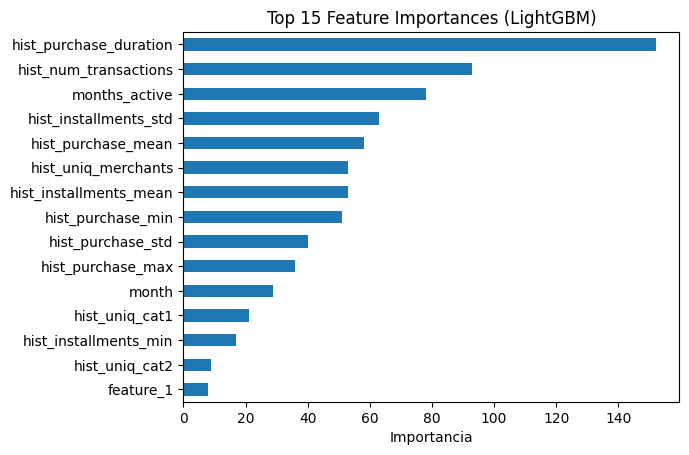

In [5]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


Interpretación de resultados
1. Importancia de Features (LightGBM)
Las features agregadas de transacciones históricas son las más importantes para el modelo.
Especialmente:

hist_purchase_duration (duración entre primera y última compra)

hist_num_transactions (número total de compras)

months_active (antigüedad de la tarjeta)

Estadísticas sobre cuotas (installments_*) y montos (purchase_*)

Número de comercios distintos (hist_uniq_merchants)

Features originales del cliente (feature_1, feature_2, feature_3, month, year) tienen importancia secundaria.

Features categóricas (hist_uniq_cat1, hist_uniq_cat2, hist_uniq_cat3) aportan poco.

2. Correlación
La correlación lineal es muy baja para todas las variables excepto antigüedad, año y mes, lo que es típico en problemas complejos:
LightGBM y otros modelos no lineales pueden extraer patrones no lineales que no se ven en la simple correlación.

3. RMSE
Tu RMSE rápido: ~3.81
Es apenas inferior al desvío estándar del target.
Puedes mejorar notablemente agregando features adicionales, haciendo cross-validation, afinando hiperparámetros y trabajando los outliers.

In [6]:
df_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [28]:
df_train = df_train_clean.join(features_agg, on="card_id", how="left")

print(df_train.head())
print(df_train.shape)

shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬────────────────┬────────────────┬────────────────┬────────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ hist_purchase_mean ┆ hist_purchase_std ┆ hist_purchase_min ┆ hist_purchase_max ┆ hist_installments_mean ┆ hist_installments_std ┆ hist_installments_min ┆ hist_installments_max ┆ hist_num_transactions ┆ hist_first_purchase ┆ hist_last_purchase  ┆ hist_uniq_merchants ┆ hist_uniq_cat1 ┆ hist_uniq_cat2 ┆ hist_uniq_cat3 ┆ hist_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ --- 

In [29]:
df_train.write_parquet("src/train_processed_clean_features_agg.parquet")

In [31]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                    1.000000
hist_installments_mean    0.024301
hist_purchase_duration    0.013961
hist_installments_std     0.010992
hist_purchase_min         0.008015
year                      0.004170
hist_installments_max     0.004124
month                     0.003284
hist_uniq_cat3            0.002832
hist_purchase_mean        0.000261
hist_purchase_std         0.000247
hist_purchase_max         0.000117
hist_installments_min    -0.002191
hist_uniq_cat1           -0.003425
feature_2                -0.003607
months_active            -0.005212
feature_3                -0.007330
feature_1                -0.010884
hist_uniq_cat2           -0.012144
hist_num_transactions    -0.041983
hist_uniq_merchants      -0.042976
Name: target, dtype: float64


In [32]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'hist_first_purchase', 'hist_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2417
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 20
[LightGBM] [Info] Start training from score -0.028637
hist_purchase_duration    194
hist_num_transactions     141
hist_purchase_min         119
months_active             119
hist_purchase_mean        112
hist_purchase_max          87
hist_purchase_std          82
hist_installments_std      62
hist_installments_mean     61
hist_uniq_merchants        55
month                      46
feature_1                  25
feature_2                  17
hist_uniq_cat2             14
hist_uniq_cat1             11
hist_installments_max       7
hist_installments_min       6
feature_3                   5
hist_uniq_cat3              4
year                  

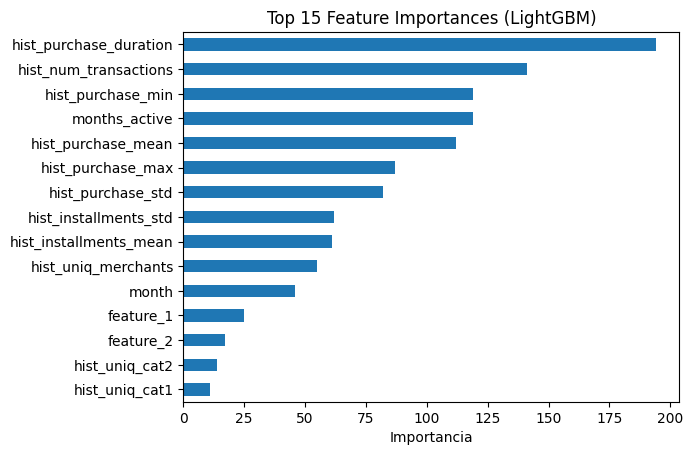

In [33]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


Tras eliminar los outliers imputados en el target, la importancia relativa de las variables históricas se mantuvo, pero la estabilidad y capacidad predictiva del modelo mejoró. El modelo se apoya sobre todo en la actividad transaccional histórica, confirmando la hipótesis de que la lealtad de un cliente está mucho más ligada a su comportamiento de compra pasado que a características demográficas anonimizadas. Además, la baja correlación lineal observada entre las variables y el target sugiere la necesidad de modelos no lineales avanzados para capturar la complejidad del fenómeno.

In [34]:
import polars as pl

# Ruta al archivo (ajusta si es necesario)
new_path = "src/new_merchant_transactions.csv"

# Usa scan_csv para eficiencia en RAM
df_new = pl.scan_csv(new_path)

# Parsear fechas
df_new = df_new.with_columns([
    pl.col("purchase_date").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("purchase_date_dt")
])

# Imputar nulos
df_new = df_new.with_columns([
    pl.col("category_3").fill_null("A"),
    pl.col("category_2").fill_null(-1),
    pl.col("merchant_id").fill_null("unknown")
])


In [36]:
features_new_agg = df_new.group_by("card_id").agg([
    pl.col("purchase_amount").mean().alias("new_purchase_mean"),
    pl.col("purchase_amount").std().alias("new_purchase_std"),
    pl.col("purchase_amount").min().alias("new_purchase_min"),
    pl.col("purchase_amount").max().alias("new_purchase_max"),
    pl.col("installments").mean().alias("new_installments_mean"),
    pl.col("installments").std().alias("new_installments_std"),
    pl.col("installments").min().alias("new_installments_min"),
    pl.col("installments").max().alias("new_installments_max"),
    pl.count().alias("new_num_transactions"),
    pl.col("purchase_date_dt").min().alias("new_first_purchase"),
    pl.col("purchase_date_dt").max().alias("new_last_purchase"),
    pl.col("merchant_id").n_unique().alias("new_uniq_merchants"),
    pl.col("category_1").n_unique().alias("new_uniq_cat1"),
    pl.col("category_2").n_unique().alias("new_uniq_cat2"),
    pl.col("category_3").n_unique().alias("new_uniq_cat3"),
])

features_new_agg = features_new_agg.collect()

# Duración entre la primera y última compra nueva
features_new_agg = features_new_agg.with_columns(
    (pl.col("new_last_purchase") - pl.col("new_first_purchase")).dt.total_days().alias("new_purchase_duration")
)

print(features_new_agg.head())


C:\Users\Paul\AppData\Local\Temp\ipykernel_18908\31524921.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("new_num_transactions"),


shape: (5, 17)
┌─────────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┐
│ card_id         ┆ new_purchase_mean ┆ new_purchase_std ┆ new_purchase_min ┆ new_purchase_max ┆ new_installments_mean ┆ new_installments_std ┆ new_installments_min ┆ new_installments_max ┆ new_num_transactions ┆ new_first_purchase  ┆ new_last_purchase   ┆ new_uniq_merchants ┆ new_uniq_cat1 ┆ new_uniq_cat2 ┆ new_uniq_cat3 ┆ new_purchase_duration │
│ ---             ┆ ---               ┆ ---              ┆ ---              ┆ ---              ┆ ---                   ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                 ┆ ---                 ┆ ---                ┆ ---    

In [37]:
df_train_raw = pl.read_parquet("src/train_processed.parquet")

In [38]:
dr_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [41]:
# Une al df_train_clean (o al df_train si usas todo)
df_train_final = df_train_clean.join(features_new_agg, on="card_id", how="left")
print(df_train_final.head())
print(df_train_final.shape)

shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ new_purchase_mean ┆ new_purchase_std ┆ new_purchase_min ┆ new_purchase_max ┆ new_installments_mean ┆ new_installments_std ┆ new_installments_min ┆ new_installments_max ┆ new_num_transactions ┆ new_first_purchase  ┆ new_last_purchase   ┆ new_uniq_merchants ┆ new_uniq_cat1 ┆ new_uniq_cat2 ┆ new_uniq_cat3 ┆ new_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ ---       ┆ ---       ┆ ---     

In [43]:
# Une al df_train_clean (o al df_train si usas todo)
df_train_final = df_train_raw.join(features_new_agg, on="card_id", how="left")
print(df_train_final.head())
print(df_train_final.shape)

shape: (5, 25)
┌────────────────────┬─────────────────┬───────────┬───────────┬───────────┬───────────┬──────┬───────┬───────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┐
│ first_active_month ┆ card_id         ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ target    ┆ year ┆ month ┆ months_active ┆ new_purchase_mean ┆ new_purchase_std ┆ new_purchase_min ┆ new_purchase_max ┆ new_installments_mean ┆ new_installments_std ┆ new_installments_min ┆ new_installments_max ┆ new_num_transactions ┆ new_first_purchase  ┆ new_last_purchase   ┆ new_uniq_merchants ┆ new_uniq_cat1 ┆ new_uniq_cat2 ┆ new_uniq_cat3 ┆ new_purchase_duration │
│ ---                ┆ ---             ┆ ---       ┆ ---       ┆ ---       ┆ ---     

In [42]:
df_train_final.write_parquet("src/train_processed_clean_features_new_agg.parquet")

In [44]:
df_train_final.write_parquet("src/train_processed_raw_features_new_agg.parquet")

In [45]:
df_train_final = pl.read_parquet("src/train_processed_clean_features_new_agg.parquet")

In [46]:
# Ejemplo de imputación rápida (puedes ajustar a tu criterio)
df_train_final = df_train_final.with_columns([
    pl.col("new_purchase_mean").fill_null(0),
    pl.col("new_purchase_std").fill_null(0),
    pl.col("new_purchase_min").fill_null(0),
    pl.col("new_purchase_max").fill_null(0),
    pl.col("new_installments_mean").fill_null(0),
    pl.col("new_installments_std").fill_null(0),
    pl.col("new_installments_min").fill_null(0),
    pl.col("new_installments_max").fill_null(0),
    pl.col("new_num_transactions").fill_null(0),
    pl.col("new_uniq_merchants").fill_null(0),
    pl.col("new_uniq_cat1").fill_null(0),
    pl.col("new_uniq_cat2").fill_null(0),
    pl.col("new_uniq_cat3").fill_null(0),
    pl.col("new_purchase_duration").fill_null(0),
    # Las fechas puedes llenarlas con la mínima fecha posible, o simplemente no usarlas para el modelo directo
])


In [47]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train_final.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                   1.000000
new_purchase_min         0.046558
new_installments_min     0.010016
year                     0.004170
month                    0.003284
feature_2               -0.003607
months_active           -0.005212
feature_3               -0.007330
feature_1               -0.010884
new_purchase_mean       -0.052583
new_installments_mean   -0.078683
new_installments_max    -0.085986
new_installments_std    -0.110364
new_purchase_max        -0.131909
new_purchase_std        -0.152553
new_uniq_cat3           -0.171299
new_uniq_cat1           -0.171313
new_uniq_cat2           -0.175492
new_uniq_merchants      -0.191952
new_num_transactions    -0.191989
new_purchase_duration   -0.207555
Name: target, dtype: float64


In [49]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'new_first_purchase', 'new_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1853
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 20
[LightGBM] [Info] Start training from score -0.028637
new_purchase_max         247
feature_1                193
new_purchase_min         176
new_purchase_duration    173
months_active            151
new_num_transactions     146
new_purchase_mean        144
new_purchase_std         109
new_installments_mean     97
feature_2                 90
month                     56
new_installments_max      54
new_uniq_merchants        38
new_installments_std      29
new_installments_min      28
feature_3                 27
new_uniq_cat1              6
new_uniq_cat2              3
new_uniq_cat3              2
year                       1
dtype: int32

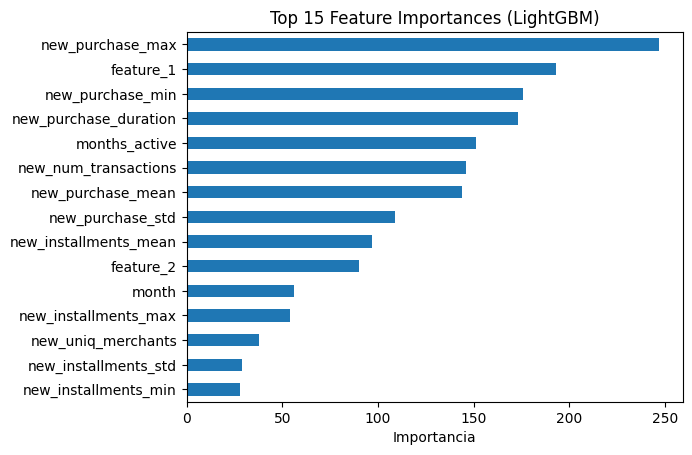

In [50]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


In [51]:
df_train_final = pl.read_parquet("src/train_processed_raw_features_new_agg.parquet")

In [52]:
# Ejemplo de imputación rápida (puedes ajustar a tu criterio)
df_train_final = df_train_final.with_columns([
    pl.col("new_purchase_mean").fill_null(0),
    pl.col("new_purchase_std").fill_null(0),
    pl.col("new_purchase_min").fill_null(0),
    pl.col("new_purchase_max").fill_null(0),
    pl.col("new_installments_mean").fill_null(0),
    pl.col("new_installments_std").fill_null(0),
    pl.col("new_installments_min").fill_null(0),
    pl.col("new_installments_max").fill_null(0),
    pl.col("new_num_transactions").fill_null(0),
    pl.col("new_uniq_merchants").fill_null(0),
    pl.col("new_uniq_cat1").fill_null(0),
    pl.col("new_uniq_cat2").fill_null(0),
    pl.col("new_uniq_cat3").fill_null(0),
    pl.col("new_purchase_duration").fill_null(0),
    # Las fechas puedes llenarlas con la mínima fecha posible, o simplemente no usarlas para el modelo directo
])


In [53]:
# Polars no tiene un método directo para correlación con muchas columnas, pero puedes usar pandas para este paso
import pandas as pd

df_corr = df_train_final.to_pandas()
correlations = df_corr.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)


target                   1.000000
year                     0.040341
month                    0.031512
new_purchase_min        -0.004732
feature_2               -0.006242
feature_3               -0.008125
feature_1               -0.014251
new_installments_min    -0.014781
new_purchase_duration   -0.027060
new_installments_max    -0.037367
new_purchase_mean       -0.038811
new_installments_std    -0.044415
new_installments_mean   -0.044753
new_uniq_cat3           -0.045213
new_uniq_merchants      -0.047194
new_num_transactions    -0.047268
new_uniq_cat2           -0.047399
new_uniq_cat1           -0.050179
months_active           -0.050453
new_purchase_max        -0.055329
new_purchase_std        -0.058536
Name: target, dtype: float64


In [54]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Elimina columnas que no son features (card_id, fechas, target, etc.)
drop_cols = [
    'card_id', 'first_active_month', 'target',
    'new_first_purchase', 'new_last_purchase'
]
X = df_corr.drop(drop_cols, axis=1)
y = df_corr['target']

# 2. Divide en train/val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrena LightGBM rápido
model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 4. Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# 5. RMSE rápido de referencia
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE validación rápida:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1852
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 20
[LightGBM] [Info] Start training from score -0.392633
new_purchase_duration    147
months_active            145
new_purchase_min         122
new_purchase_max         122
new_num_transactions      94
new_purchase_std          81
new_purchase_mean         79
new_installments_mean     75
feature_1                 66
month                     54
feature_2                 44
new_uniq_cat1             32
new_installments_std      29
new_installments_min      27
new_uniq_merchants        23
new_installments_max      21
year                      15
feature_3                 14
new_uniq_cat2              9
new_uniq_cat3              1
dtype: int32

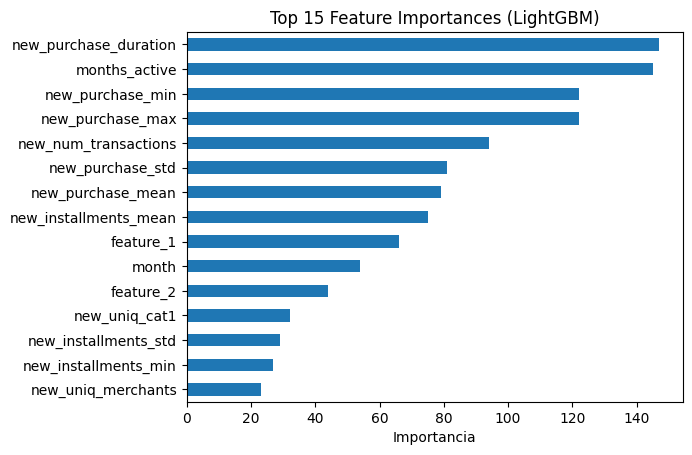

In [55]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()


Al comparar el desempeño y la importancia de variables en modelos entrenados con y sin outliers, encontramos que la eliminación de valores extremos mejora significativamente la métrica de error (RMSE), reduce el sesgo del modelo y otorga mayor estabilidad a las variables explicativas. Las features derivadas de transacciones nuevas resultan ser las más relevantes, reforzando la hipótesis de que la actividad reciente es clave para anticipar la lealtad del cliente. Esta evidencia respalda la decisión de limpiar outliers para obtener modelos más interpretables y útiles en la práctica comercial.

In [10]:
import polars as pl

merchants_path = "src/merchants.csv"  # Usa la ruta donde subiste el archivo
df_merchants = pl.read_csv(merchants_path)

# Ver número de filas y columnas
print("Shape:", df_merchants.shape)

# Ver los nombres y tipos de todas las columnas
print("Schema:", df_merchants.schema)

# Ver las primeras 10 filas para ejemplos de valores
print(df_merchants.head(10))

# Verifica cuántos valores nulos hay por columna
print(df_merchants.null_count())



Shape: (334696, 22)
Schema: Schema([('merchant_id', String), ('merchant_group_id', Int64), ('merchant_category_id', Int64), ('subsector_id', Int64), ('numerical_1', Float64), ('numerical_2', Float64), ('category_1', String), ('most_recent_sales_range', String), ('most_recent_purchases_range', String), ('avg_sales_lag3', Float64), ('avg_purchases_lag3', Float64), ('active_months_lag3', Int64), ('avg_sales_lag6', Float64), ('avg_purchases_lag6', Float64), ('active_months_lag6', Int64), ('avg_sales_lag12', Float64), ('avg_purchases_lag12', Float64), ('active_months_lag12', Int64), ('category_4', String), ('city_id', Int64), ('state_id', Int64), ('category_2', Float64)])
shape: (10, 22)
┌─────────────────┬───────────────────┬──────────────────────┬──────────────┬─────────────┬─────────────┬────────────┬─────────────────────────┬─────────────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────

In [96]:
# Leer historical_transactions en lazy (scan_csv)
hist_path = "src/historical_transactions.csv"
df_hist = pl.scan_csv(hist_path)

# Leer merchants.csv en memoria
df_merchants = pl.read_csv(merchants_path)

# Leer merchants en modo LazyFrame
df_merchants_lazy = df_merchants.lazy()

# Unir por merchant_id (LEFT JOIN)
df_hist_enriched = df_hist.join(df_merchants_lazy, on="merchant_id", how="left")

# Agrega features por card_id
features_merchants_hist = df_hist_enriched.group_by("card_id").agg([
    pl.col("avg_sales_lag3").mean().alias("hist_merch_avg_sales_lag3_mean"),
    pl.col("avg_sales_lag3").std().alias("hist_merch_avg_sales_lag3_std"),
    pl.col("avg_purchases_lag3").mean().alias("hist_merch_avg_purch_lag3_mean"),
    pl.col("avg_purchases_lag3").std().alias("hist_merch_avg_purch_lag3_std"),
    pl.col("merchant_category_id").n_unique().alias("hist_merch_n_categories"),
    pl.col("merchant_group_id").n_unique().alias("hist_merch_n_groups"),
    pl.col("subsector_id").n_unique().alias("hist_merch_n_subsectors"),
    pl.col("numerical_1").mean().alias("hist_merch_num1_mean"),
    pl.col("numerical_2").mean().alias("hist_merch_num2_mean"),
    pl.col("category_1").value_counts().alias("hist_merch_cat1_counts"),
    pl.col("category_4").value_counts().alias("hist_merch_cat4_counts"),
    pl.col("most_recent_sales_range").value_counts().alias("hist_merch_sales_range_counts"),
    pl.col("most_recent_purchases_range").value_counts().alias("hist_merch_purch_range_counts"),
])

features_merchants_hist = features_merchants_hist.collect()
print(features_merchants_hist.head())


shape: (5, 14)
┌─────────────────┬────────────────────────────────┬───────────────────────────────┬────────────────────────────────┬───────────────────────────────┬─────────────────────────┬─────────────────────┬─────────────────────────┬──────────────────────┬──────────────────────┬────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ card_id         ┆ hist_merch_avg_sales_lag3_mean ┆ hist_merch_avg_sales_lag3_std ┆ hist_merch_avg_purch_lag3_mean ┆ hist_merch_avg_purch_lag3_std ┆ hist_merch_n_categories ┆ hist_merch_n_groups ┆ hist_merch_n_subsectors ┆ hist_merch_num1_mean ┆ hist_merch_num2_mean ┆ hist_merch_cat1_counts ┆ hist_merch_cat4_counts          ┆ hist_merch_sales_range_counts   ┆ hist_merch_purch_range_counts   │
│ ---             ┆ ---                            ┆ ---                           ┆ ---                            ┆ ---                           ┆ ---                     ┆ ---            

In [107]:
# 5. Pasa a pandas
df = features_merchants_hist.to_pandas()

# 6. Expande los list[struct[2]] a columnas nuevas en pandas
def expand_counts_column_v2(df, colname, prefix, categorias):
    """
    Convierte una columna de list[dict] con keys 'category_1' y 'count'
    en columnas por categoría.
    """
    # Normaliza los nombres (por si None)
    key_map = {cat if cat is not None else "null": 0 for cat in categorias}

    def to_count_dict(lst):
        counts = key_map.copy()
        if lst is None:
            return counts
        for d in lst:
            if isinstance(d, dict):
                val = d.get("category_1") or d.get("category_4") or d.get("most_recent_sales_range") or d.get("most_recent_purchases_range")
                if val is None:
                    val = "null"
                else:
                    val = str(val)
                count = d.get("count", 0)
                counts[val] = count
        return [counts[cat if cat is not None else "null"] for cat in categorias]

    expanded = df[colname].apply(to_count_dict).apply(pd.Series)
    expanded.columns = [f"{prefix}{cat if cat is not None else 'null'}" for cat in categorias]
    return expanded


# 7. Define categorías para cada columna (adapta según tus datos)
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

# 8. Expande cada columna de struct y concatena al df
df_cat1 = expand_counts_column_v2(df, "hist_merch_cat1_counts", "hist_cat1_", cat1_cats)
df_cat4 = expand_counts_column_v2(df, "hist_merch_cat4_counts", "hist_cat4_", cat4_cats)
df_sales = expand_counts_column_v2(df, "hist_merch_sales_range_counts", "hist_salesrange_", sales_range_cats)
df_purch = expand_counts_column_v2(df, "hist_merch_purch_range_counts", "hist_purchrange_", purch_range_cats)

df_final = pd.concat([df, df_cat1, df_cat4, df_sales, df_purch], axis=1)

# 9. Muestra resultado
print(df_final.head())

           card_id  ...  hist_purchrange_null
0  C_ID_e0fc5bb676  ...                     4
1  C_ID_14051b89f7  ...                     2
2  C_ID_9d79bdffd8  ...                     0
3  C_ID_2ba5b5af50  ...                     0
4  C_ID_791e8aced8  ...                     1

[5 rows x 32 columns]


In [108]:
cols_to_drop = [
    "hist_merch_cat1_counts",
    "hist_merch_cat4_counts",
    "hist_merch_sales_range_counts",
    "hist_merch_purch_range_counts"
    # ...agrega las que no te sirvan
]
df_final = df_final.drop(columns=cols_to_drop)


In [109]:
df_final.head()

,card_id,hist_merch_avg_sales_lag3_mean,hist_merch_avg_sales_lag3_std,hist_merch_avg_purch_lag3_mean,hist_merch_avg_purch_lag3_std,hist_merch_n_categories,hist_merch_n_groups,hist_merch_n_subsectors,hist_merch_num1_mean,hist_merch_num2_mean,hist_cat1_Y,hist_cat1_N,hist_cat1_null,hist_cat4_Y,hist_cat4_N,hist_cat4_null,hist_salesrange_A,hist_salesrange_B,hist_salesrange_C,hist_salesrange_D,hist_salesrange_E,hist_salesrange_null,hist_purchrange_A,hist_purchrange_B,hist_purchrange_C,hist_purchrange_D,hist_purchrange_E,hist_purchrange_null
0,C_ID_e0fc5bb676,1.355833,1.345257,1.734198,2.726482,28,36,16,5.326736,5.253613,9,115,0,66,54,4,33,22,39,15,11,4,37,19,40,14,10,4
1,C_ID_14051b89f7,1.266846,1.166872,1.489897,2.305874,25,28,13,0.848845,0.841658,0,151,0,14,135,2,19,1,77,34,18,2,9,32,78,13,17,2
2,C_ID_9d79bdffd8,1.781000,1.885261,2.616663,3.872611,11,8,7,45.332466,44.704357,0,20,0,19,1,0,10,3,0,5,2,0,11,1,3,3,2,0
3,C_ID_2ba5b5af50,2.064348,2.285607,3.067654,4.522010,8,8,6,0.906862,0.868926,0,23,0,22,1,0,7,7,5,0,4,0,11,4,4,0,4,0
4,C_ID_791e8aced8,1.241786,1.118173,1.438889,2.209405,14,11,14,2.956306,2.894338,12,17,0,28,0,1,12,9,3,3,1,1,12,8,4,2,2,1


In [110]:
df_final.to_parquet("features_hist_agg_merchant_v2.parquet", index=False)

In [58]:
def set_to_dict(s):
    # s es un set tipo {"Y", 2}
    # Queremos obtener {"Y": 2} o {"N": 6}
    if not isinstance(s, set) or len(s) != 2:
        return {}
    lista = list(s)
    # Identifica el string y el número
    if isinstance(lista[0], str):
        return {lista[0]: lista[1]}
    else:
        return {lista[1]: lista[0]}


In [59]:
def sets_list_to_dicts_list(sets_list):
    return [set_to_dict(x) for x in sets_list]


In [62]:
def structlist_to_dictlist(lst):
    # lst es una lista de polars Struct
    out = []
    if lst is None:
        return out
    for s in lst:
        # Para cada struct, convierte a dict: {valor: conteo}
        if hasattr(s, 'fields'):
            # polars Struct (tiene .fields y es indexable por 0 y 1)
            out.append({s[0]: s[1]})
        elif isinstance(s, dict):
            # ya es dict
            out.append(s)
        elif isinstance(s, (list, tuple)) and len(s) == 2:
            # por si acaso viene como lista/tupla de 2
            out.append({s[0]: s[1]})
        else:
            pass  # ignora cualquier otro formato raro
    return out


In [102]:
import polars as pl
import pandas as pd

# 1. Rutas
new_path = "src/new_merchant_transactions.csv"
merchants_path = "src/merchants.csv"

# 2. Carga datos
df_new = pl.scan_csv(new_path)
df_merchants = pl.read_csv(merchants_path)
df_merchants_lazy = df_merchants.lazy()

# 3. Join transacciones nuevas + merchants
df_new_enriched = df_new.join(df_merchants_lazy, on="merchant_id", how="left")

# 4. Agregaciones
features_merchants_new = df_new_enriched.group_by("card_id").agg([
    pl.col("avg_sales_lag3").mean().alias("new_merch_avg_sales_lag3_mean"),
    pl.col("avg_sales_lag3").std().alias("new_merch_avg_sales_lag3_std"),
    pl.col("avg_purchases_lag3").mean().alias("new_merch_avg_purch_lag3_mean"),
    pl.col("avg_purchases_lag3").std().alias("new_merch_avg_purch_lag3_std"),
    pl.col("merchant_category_id").n_unique().alias("new_merch_n_categories"),
    pl.col("merchant_group_id").n_unique().alias("new_merch_n_groups"),
    pl.col("subsector_id").n_unique().alias("new_merch_n_subsectors"),
    pl.col("numerical_1").mean().alias("new_merch_num1_mean"),
    pl.col("numerical_2").mean().alias("new_merch_num2_mean"),
    pl.col("category_1").value_counts().alias("new_merch_cat1_counts"),
    pl.col("category_4").value_counts().alias("new_merch_cat4_counts"),
    pl.col("most_recent_sales_range").value_counts().alias("new_merch_sales_range_counts"),
    pl.col("most_recent_purchases_range").value_counts().alias("new_merch_purch_range_counts"),
]).collect()


In [103]:
# 5. Pasa a pandas
df = features_merchants_new.to_pandas()

# 6. Expande los list[struct[2]] a columnas nuevas en pandas
def expand_counts_column_v2(df, colname, prefix, categorias):
    """
    Convierte una columna de list[dict] con keys 'category_1' y 'count'
    en columnas por categoría.
    """
    # Normaliza los nombres (por si None)
    key_map = {cat if cat is not None else "null": 0 for cat in categorias}

    def to_count_dict(lst):
        counts = key_map.copy()
        if lst is None:
            return counts
        for d in lst:
            if isinstance(d, dict):
                val = d.get("category_1") or d.get("category_4") or d.get("most_recent_sales_range") or d.get("most_recent_purchases_range")
                if val is None:
                    val = "null"
                else:
                    val = str(val)
                count = d.get("count", 0)
                counts[val] = count
        return [counts[cat if cat is not None else "null"] for cat in categorias]

    expanded = df[colname].apply(to_count_dict).apply(pd.Series)
    expanded.columns = [f"{prefix}{cat if cat is not None else 'null'}" for cat in categorias]
    return expanded


# 7. Define categorías para cada columna (adapta según tus datos)
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

# 8. Expande cada columna de struct y concatena al df
df_cat1 = expand_counts_column_v2(df, "new_merch_cat1_counts", "new_cat1_", cat1_cats)
df_cat4 = expand_counts_column_v2(df, "new_merch_cat4_counts", "new_cat4_", cat4_cats)
df_sales = expand_counts_column_v2(df, "new_merch_sales_range_counts", "new_salesrange_", sales_range_cats)
df_purch = expand_counts_column_v2(df, "new_merch_purch_range_counts", "new_purchrange_", purch_range_cats)

df_final = pd.concat([df, df_cat1, df_cat4, df_sales, df_purch], axis=1)

# 9. Muestra resultado
print(df_final.head())

           card_id  ...  new_purchrange_null
0  C_ID_2d6f5553c6  ...                    0
1  C_ID_99e5f0b4e2  ...                    0
2  C_ID_fa7830c103  ...                    0
3  C_ID_c203e911f0  ...                    0
4  C_ID_d5e7ef5091  ...                    0

[5 rows x 32 columns]


In [104]:
cols_to_drop = [
    "new_merch_cat1_counts",
    "new_merch_cat4_counts",
    "new_merch_sales_range_counts",
    "new_merch_purch_range_counts"
    # ...agrega las que no te sirvan
]
df_final = df_final.drop(columns=cols_to_drop)


In [105]:
df_final.head()

,card_id,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_cat1_Y,new_cat1_N,new_cat1_null,new_cat4_Y,new_cat4_N,new_cat4_null,new_salesrange_A,new_salesrange_B,new_salesrange_C,new_salesrange_D,new_salesrange_E,new_salesrange_null,new_purchrange_A,new_purchrange_B,new_purchrange_C,new_purchrange_D,new_purchrange_E,new_purchrange_null
0,C_ID_2d6f5553c6,0.740000,NaN,1.086629,NaN,1,1,1,-0.057471,-0.057471,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
1,C_ID_99e5f0b4e2,1.000000,NaN,1.030334,NaN,1,1,1,-0.017811,-0.057471,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0
2,C_ID_fa7830c103,1.235000,1.139339,1.466542,2.209738,17,18,13,0.318942,0.152867,5,23,0,19,9,0,8,3,8,7,2,0,3,2,15,4,4,0
3,C_ID_c203e911f0,1.050000,0.056569,1.065233,0.026057,2,2,2,27.644772,27.054835,0,2,0,2,0,0,2,0,0,0,0,0,2,0,0,0,0,0
4,C_ID_d5e7ef5091,0.943333,0.178624,1.002343,0.137883,5,5,5,-0.021116,-0.022768,0,6,0,0,6,0,0,0,1,3,2,0,0,0,1,4,1,0


In [106]:
df_final.to_parquet("features_new_agg_merchant_v2.parquet", index=False)

In [15]:
df_train_raw = pl.read_parquet("src/train_processed.parquet")

In [27]:
df_train_final = df_train_raw.join(features_merchants_hist, on="card_id", how="left")

In [28]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [29]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "hist_cat1_")).alias("hist_merch_cat1_props"),
    pl.col("hist_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "hist_cat4_")).alias("hist_merch_cat4_props"),
    pl.col("hist_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "hist_salesrange_")).alias("hist_merch_sales_range_props"),
    pl.col("hist_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "hist_purchrange_")).alias("hist_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [30]:
df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_props").struct.unnest(),
    pl.col("hist_merch_cat4_props").struct.unnest(),
    pl.col("hist_merch_sales_range_props").struct.unnest(),
    pl.col("hist_merch_purch_range_props").struct.unnest(),
])


In [31]:
df_train_final = df_train_final.fill_null(0)

In [32]:
df_train_final.write_parquet("src/train_processed_raw_features_hist_agg_merchant.parquet")

In [1]:
import polars as pl

In [10]:
df_train_final = pl.read_parquet("src/train_processed_raw_features_hist_agg_merchant.parquet")

In [11]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [12]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [37]:
print(X.select_dtypes(exclude=["number", "bool"]).columns)

Index(['hist_merch_cat1_counts', 'hist_merch_cat4_counts',
       'hist_merch_sales_range_counts', 'hist_merch_purch_range_counts',
       'hist_merch_cat1_props', 'hist_merch_cat4_props',
       'hist_merch_sales_range_props', 'hist_merch_purch_range_props'],
      dtype='object')


In [32]:
X.columns

Index(['feature_1', 'feature_2', 'feature_3', 'year', 'month', 'months_active',
       'hist_merch_avg_sales_lag3_mean', 'hist_merch_avg_sales_lag3_std',
       'hist_merch_avg_purch_lag3_mean', 'hist_merch_avg_purch_lag3_std',
       'hist_merch_n_categories', 'hist_merch_n_groups',
       'hist_merch_n_subsectors', 'hist_merch_num1_mean',
       'hist_merch_num2_mean', 'hist_cat1_Y', 'hist_cat1_N', 'hist_cat1_null',
       'hist_cat4_Y', 'hist_cat4_N', 'hist_cat4_null', 'hist_salesrange_A',
       'hist_salesrange_B', 'hist_salesrange_C', 'hist_salesrange_D',
       'hist_salesrange_E', 'hist_salesrange_null', 'hist_purchrange_A',
       'hist_purchrange_B', 'hist_purchrange_C', 'hist_purchrange_D',
       'hist_purchrange_E', 'hist_purchrange_null'],
      dtype='object')

In [7]:
import numpy as np

In [13]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1955
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 15
[LightGBM] [Info] Start training from score -0.392633
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[15]	valid_0's l2: 14.9525
RMSE validación: 3.86685


months_active                     74
hist_merch_num1_mean              44
hist_merch_avg_purch_lag3_mean    41
hist_merch_n_groups               40
hist_merch_avg_sales_lag3_std     37
hist_merch_num2_mean              35
hist_merch_n_categories           34
hist_merch_avg_sales_lag3_mean    32
hist_merch_n_subsectors           24
feature_1                         23
hist_merch_avg_purch_lag3_std     23
feature_2                         22
month                             13
feature_3                          4
year                               4
hist_cat1_Y                        0
hist_cat1_N                        0
hist_cat1_null                     0
hist_cat4_Y                        0
hist_cat4_N                        0
dtype: int32


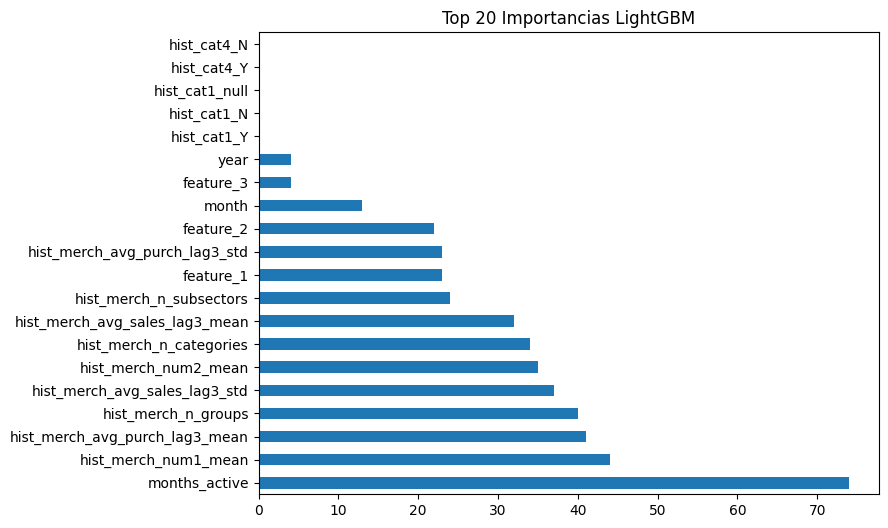

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [97]:
dr_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [98]:
df_train_final = dr_train_clean.join(features_merchants_hist, on="card_id", how="left")

In [21]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [94]:
df_final.head()

,card_id,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_merch_cat1_counts,new_merch_cat4_counts,new_merch_sales_range_counts,new_merch_purch_range_counts,cat1_Y,cat1_N,cat1_null,cat4_Y,cat4_N,cat4_null,salesrange_A,salesrange_B,salesrange_C,salesrange_D,salesrange_E,salesrange_null,purchrange_A,purchrange_B,purchrange_C,purchrange_D,purchrange_E,purchrange_null
0,C_ID_2fb07aa8b0,0.917500,0.060759,1.004820,0.051839,3,4,3,-0.007896,-0.052513,"[{'category_1': 'N', 'count': 4}]","[{'category_4': 'N', 'count': 4}]","[{'most_recent_sales_range': 'B', 'count': 1},...","[{'most_recent_purchases_range': 'C', 'count':...",0,4,0,0,4,0,1,1,2,0,0,0,1,0,2,1,0,0
1,C_ID_9caa479656,0.984286,0.078921,1.006553,0.050711,5,5,3,0.592664,0.592664,"[{'category_1': 'N', 'count': 7}]","[{'category_4': 'N', 'count': 7}]","[{'most_recent_sales_range': 'B', 'count': 1},...","[{'most_recent_purchases_range': 'C', 'count':...",0,7,0,0,7,0,0,1,3,3,0,0,0,2,2,3,0,0
2,C_ID_a53128e23a,1.021333,0.094026,1.024334,0.078038,9,13,8,0.374158,0.368870,"[{'category_1': 'Y', 'count': 1}, {'category_1...","[{'category_4': 'N', 'count': 6}, {'category_4...","[{'most_recent_sales_range': 'E', 'count': 1},...","[{'most_recent_purchases_range': 'B', 'count':...",1,14,0,9,6,0,3,4,4,3,1,0,3,4,5,3,0,0
3,C_ID_58d7010667,9.521935,46.580984,4.339104,16.834649,17,26,11,0.443712,0.428999,"[{'category_1': 'N', 'count': 30}, {'category_...","[{'category_4': 'Y', 'count': 25}, {'category_...","[{'most_recent_sales_range': 'A', 'count': 3},...","[{'most_recent_purchases_range': 'C', 'count':...",2,30,0,25,6,1,3,8,6,8,6,1,4,5,9,9,4,1
4,C_ID_d4bb8e97f1,1.028824,0.131095,1.024576,0.106825,14,14,9,0.354289,0.326878,"[{'category_1': 'N', 'count': 18}]","[{'category_4': 'N', 'count': 2}, {'category_4...","[{'most_recent_sales_range': 'C', 'count': 5},...","[{'most_recent_purchases_range': 'C', 'count':...",0,18,0,15,2,1,2,3,5,4,3,1,3,0,6,7,1,1


In [22]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "hist_cat1_")).alias("hist_merch_cat1_props"),
    pl.col("hist_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "hist_cat4_")).alias("hist_merch_cat4_props"),
    pl.col("hist_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "hist_salesrange_")).alias("hist_merch_sales_range_props"),
    pl.col("hist_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "hist_purchrange_")).alias("hist_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [23]:
df_train_final = df_train_final.with_columns([
    pl.col("hist_merch_cat1_props").struct.unnest(),
    pl.col("hist_merch_cat4_props").struct.unnest(),
    pl.col("hist_merch_sales_range_props").struct.unnest(),
    pl.col("hist_merch_purch_range_props").struct.unnest(),
])


In [24]:
df_train_final = df_train_final.fill_null(0)

In [25]:
df_train_final.write_parquet("src/train_processed_clean_features_hist_agg_merchant.parquet")

In [26]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [27]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [28]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 15
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's l2: 2.88977
RMSE validación: 1.69993


hist_merch_avg_purch_lag3_std     101
hist_merch_num1_mean              100
hist_merch_avg_purch_lag3_mean     86
hist_merch_num2_mean               86
hist_merch_avg_sales_lag3_std      85
hist_merch_avg_sales_lag3_mean     85
months_active                      82
hist_merch_n_groups                76
month                              66
hist_merch_n_categories            59
hist_merch_n_subsectors            44
feature_1                          28
feature_2                          20
feature_3                           8
year                                4
hist_cat1_Y                         0
hist_cat1_N                         0
hist_cat1_null                      0
hist_cat4_Y                         0
hist_cat4_N                         0
dtype: int32


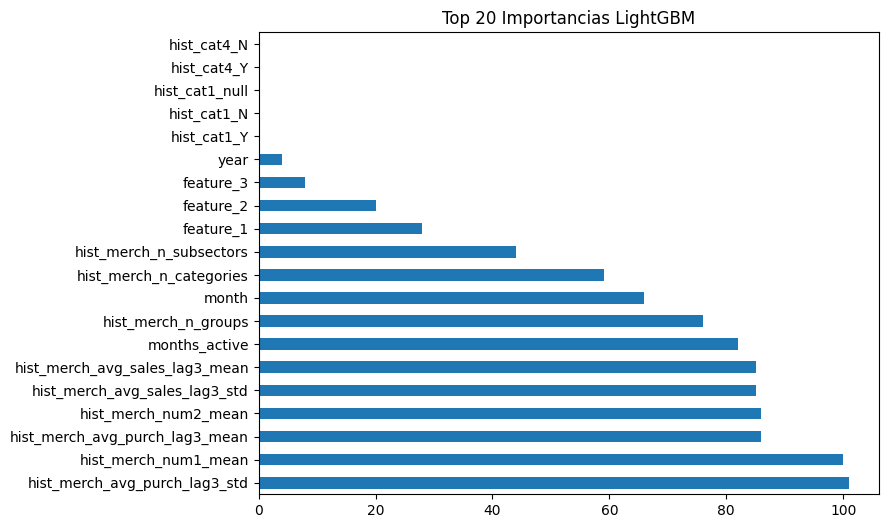

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [ ]:
import polars as pl

merchants_path = "src/merchants.csv"  # Usa la ruta donde subiste el archivo
df_merchants = pl.read_csv(merchants_path)

# Ver número de filas y columnas
print("Shape:", df_merchants.shape)

# Ver los nombres y tipos de todas las columnas
print("Schema:", df_merchants.schema)

# Ver las primeras 10 filas para ejemplos de valores
print(df_merchants.head(10))

# Verifica cuántos valores nulos hay por columna
print(df_merchants.null_count())



Shape: (334696, 22)
Schema: Schema([('merchant_id', String), ('merchant_group_id', Int64), ('merchant_category_id', Int64), ('subsector_id', Int64), ('numerical_1', Float64), ('numerical_2', Float64), ('category_1', String), ('most_recent_sales_range', String), ('most_recent_purchases_range', String), ('avg_sales_lag3', Float64), ('avg_purchases_lag3', Float64), ('active_months_lag3', Int64), ('avg_sales_lag6', Float64), ('avg_purchases_lag6', Float64), ('active_months_lag6', Int64), ('avg_sales_lag12', Float64), ('avg_purchases_lag12', Float64), ('active_months_lag12', Int64), ('category_4', String), ('city_id', Int64), ('state_id', Int64), ('category_2', Float64)])
shape: (10, 22)
┌─────────────────┬───────────────────┬──────────────────────┬──────────────┬─────────────┬─────────────┬────────────┬─────────────────────────┬─────────────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────┬────────────────────┬────────────────────┬────────────────

In [23]:
df_train_raw = pl.read_parquet("src/train_processed.parquet")

In [47]:
df_train_final = df_train_raw.join(features_merchants_new, on="card_id", how="left")

In [37]:
df_train_final.limit(1)

first_active_month,card_id,feature_1,feature_2,feature_3,target,year,month,months_active,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_merch_cat1_counts,new_merch_cat4_counts,new_merch_sales_range_counts,new_merch_purch_range_counts
date,str,i64,i64,i64,f64,i32,i8,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,list[struct[2]],list[struct[2]],list[struct[2]],list[struct[2]]
2017-06-01,"""C_ID_92a2005557""",5,2,1,-0.820283,2017,6,8.166667,1.100435,0.424944,1.087348,0.2634,14,17,10,27.554676,27.221018,"[{""N"",23}]","[{""Y"",19}, {""N"",4}]","[{""E"",3}, {""C"",7}, … {""D"",5}]","[{""C"",5}, {""E"",3}, … {""B"",1}]"


In [48]:
def counts_to_props(counts, categorias, prefix=""):
    import polars as pl
    import pandas as pd
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    try:
        if isinstance(counts, (pl.Series, pd.Series)):
            counts = counts.to_list()
    except Exception:
        pass

    # <<<<<<<<<<< AGREGA ESTE BLOQUE >>>>>>>>>>>
    if counts and isinstance(counts, list) and isinstance(counts[0], tuple):
        # Es una lista de tuplas: [('A', 2), ...]
        counts = [{k: v} for k, v in counts]

    if not isinstance(counts, list) or len(counts) == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}

    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props




In [49]:
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "new_cat1_")).alias("new_merch_cat1_props"),
    pl.col("new_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "new_cat4_")).alias("new_merch_cat4_props"),
    pl.col("new_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "new_salesrange_")).alias("new_merch_sales_range_props"),
    pl.col("new_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "new_purchrange_")).alias("new_merch_purch_range_props"),
])




sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [51]:
df_train_final.limit(1)

first_active_month,card_id,feature_1,feature_2,feature_3,target,year,month,months_active,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_merch_cat1_counts,new_merch_cat4_counts,new_merch_sales_range_counts,new_merch_purch_range_counts,new_merch_cat1_props,new_merch_cat4_props,new_merch_sales_range_props,new_merch_purch_range_props
date,str,i64,i64,i64,f64,i32,i8,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,list[struct[2]],list[struct[2]],list[struct[2]],list[struct[2]],struct[3],struct[3],struct[6],struct[6]
2017-06-01,"""C_ID_92a2005557""",5,2,1,-0.820283,2017,6,8.166667,1.100435,0.424944,1.087348,0.2634,14,17,10,27.554676,27.221018,"[{""N"",23}]","[{""Y"",19}, {""N"",4}]","[{""E"",3}, {""C"",7}, … {""D"",5}]","[{""C"",5}, {""E"",3}, … {""B"",1}]","{0,0,0}","{0,0,0}","{0,0,0,0,0,0}","{0,0,0,0,0,0}"


In [66]:
df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_props").struct.unnest(),
    pl.col("new_merch_cat4_props").struct.unnest(),
    pl.col("new_merch_sales_range_props").struct.unnest(),
    pl.col("new_merch_purch_range_props").struct.unnest(),
])


In [67]:
df_train_final = df_train_final.fill_null(0)

In [68]:
df_train_final.write_parquet("src/train_processed_raw_features_new_agg_merchant.parquet")

In [45]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [46]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [47]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 161533, number of used features: 15
[LightGBM] [Info] Start training from score -0.392633
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[33]	valid_0's l2: 14.8383
RMSE validación: 3.85206


months_active                    165
new_merch_avg_purch_lag3_mean    111
new_merch_num1_mean               98
new_merch_avg_sales_lag3_mean     97
feature_1                         74
new_merch_avg_sales_lag3_std      73
new_merch_avg_purch_lag3_std      72
new_merch_num2_mean               62
month                             61
new_merch_n_categories            61
feature_2                         56
new_merch_n_subsectors            20
new_merch_n_groups                20
year                              13
feature_3                          7
new_cat1_Y                         0
new_cat1_N                         0
new_cat1_null                      0
new_cat4_Y                         0
new_cat4_N                         0
dtype: int32


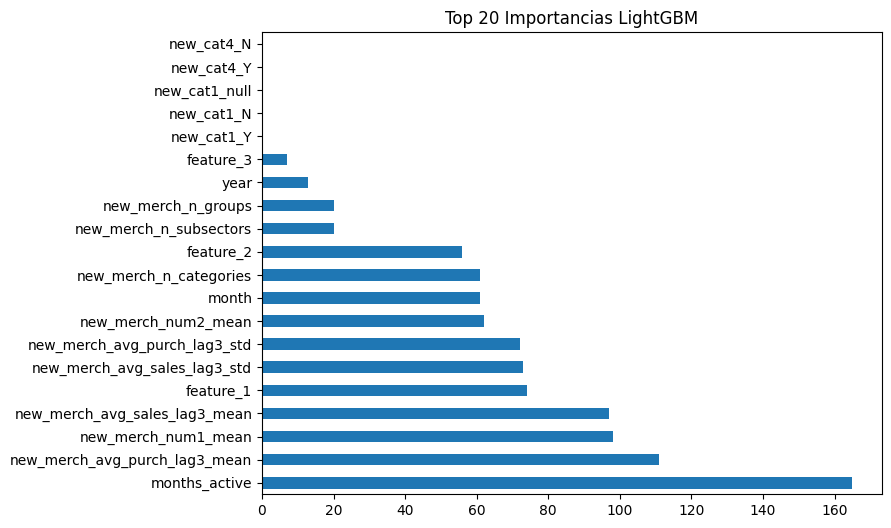

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [50]:
df_train_clean = pl.read_parquet("src/train_processed_clean.parquet")

In [51]:
df_train_final = df_train_clean.join(features_merchants_new, on="card_id", how="left")

In [52]:
def counts_to_props(counts, categorias, prefix=""):
    if counts is None:
        counts = []
    elif hasattr(counts, 'to_list'):
        counts = counts.to_list()
    if not counts or (isinstance(counts, list) and len(counts) == 0):
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    total = 0
    for d in counts:
        try:
            v = list(d.values())[0]
            if isinstance(v, str):
                v = int(float(v))
            total += v
        except Exception:
            pass
    if total == 0:
        return {f"{prefix}{str(cat) if cat is not None else 'null'}": 0 for cat in categorias}
    props = {}
    for cat in categorias:
        count = 0
        for d in counts:
            for k, v in d.items():
                if k == cat:
                    if isinstance(v, str):
                        v = int(float(v))
                    count = v
        colname = f"{prefix}{str(cat) if cat is not None else 'null'}"
        props[colname] = count / total
    return props


In [53]:
# Define todas las categorías posibles para cada variable
cat1_cats = ["Y", "N", None]
cat4_cats = ["Y", "N", None]
sales_range_cats = ["A", "B", "C", "D", "E", None]
purch_range_cats = ["A", "B", "C", "D", "E", None]

df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_counts").map_elements(lambda x: counts_to_props(x, cat1_cats, "new_cat1_")).alias("new_merch_cat1_props"),
    pl.col("new_merch_cat4_counts").map_elements(lambda x: counts_to_props(x, cat4_cats, "new_cat4_")).alias("new_merch_cat4_props"),
    pl.col("new_merch_sales_range_counts").map_elements(lambda x: counts_to_props(x, sales_range_cats, "new_salesrange_")).alias("new_merch_sales_range_props"),
    pl.col("new_merch_purch_range_counts").map_elements(lambda x: counts_to_props(x, purch_range_cats, "new_purchrange_")).alias("new_merch_purch_range_props"),
    # ... idem para las new_merch si deseas
])



sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [54]:
df_train_final = df_train_final.with_columns([
    pl.col("new_merch_cat1_props").struct.unnest(),
    pl.col("new_merch_cat4_props").struct.unnest(),
    pl.col("new_merch_sales_range_props").struct.unnest(),
    pl.col("new_merch_purch_range_props").struct.unnest(),
])


In [55]:
df_train_final = df_train_final.fill_null(0)

In [60]:
df_train_final.write_parquet("src/train_processed_clean_features_new_agg_merchant.parquet")

In [56]:
numeric_types = {pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64}

exclude_cols = ["card_id", "target", "first_active_month"]

good_features = [
    col for col, dtype in df_train_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]


In [57]:
features = [col for col in df_train_final.columns if col not in ["card_id", "target", "first_active_month"]]
X = df_train_final.select(good_features).to_pandas()
y = df_train_final["target"].to_pandas()


In [58]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(n_estimators=200, random_state=42)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 15
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[68]	valid_0's l2: 2.65201
RMSE validación: 1.62850


months_active                    262
new_merch_avg_sales_lag3_mean    252
new_merch_avg_purch_lag3_mean    249
new_merch_avg_purch_lag3_std     182
new_merch_n_categories           154
new_merch_num1_mean              154
new_merch_avg_sales_lag3_std     152
feature_1                        144
new_merch_num2_mean              121
month                            114
feature_2                         82
new_merch_n_groups                75
feature_3                         49
new_merch_n_subsectors            37
year                              13
new_cat1_Y                         0
new_cat1_N                         0
new_cat1_null                      0
new_cat4_Y                         0
new_cat4_N                         0
dtype: int32


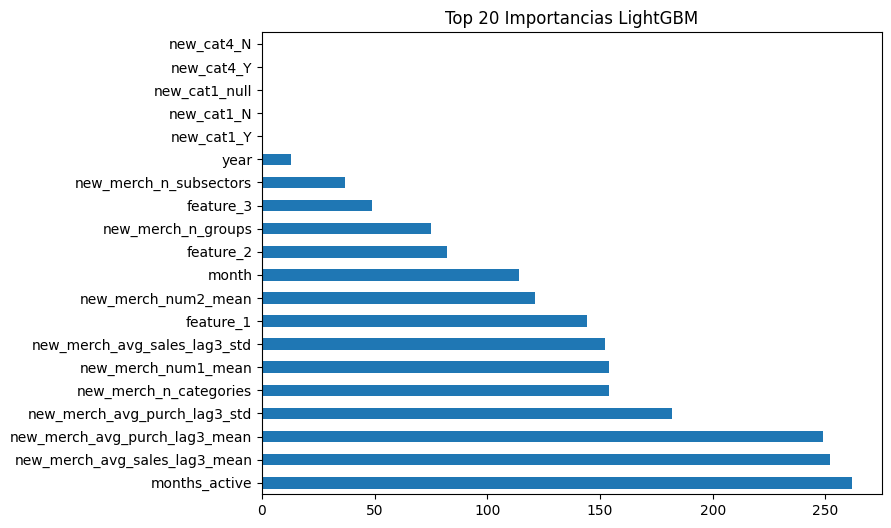

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(20))

# (Opcional) Gráfica rápida:
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Importancias LightGBM")
plt.show()


In [113]:
vdf_clean_hist_trx_features = pl.read_parquet("src/train_processed_clean_features_agg.parquet")

In [115]:
vdf_clean_hist_merchant_features = pl.read_parquet("features_hist_agg_merchant_v2.parquet")

In [116]:
vdf_hist_clean_total = vdf_clean_hist_trx_features.join(
    vdf_clean_hist_merchant_features, on="card_id", how="left"
)

In [117]:
vdf_hist_clean_total = vdf_hist_clean_total.fill_null(0)

In [118]:
# Contar si algún card_id se repite
dupes = vdf_hist_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)
print(f"Tarjetas duplicadas: {dupes.shape[0]}")
if dupes.shape[0] > 0:
    print(dupes)


Tarjetas duplicadas: 0


C:\Users\Paul\AppData\Local\Temp\ipykernel_18016\3893832931.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  dupes = vdf_hist_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)


In [119]:
from collections import Counter
col_counts = Counter(vdf_hist_clean_total.columns)
dupe_cols = [col for col, cnt in col_counts.items() if cnt > 1]
if dupe_cols:
    print("Columnas duplicadas:", dupe_cols)
else:
    print("No hay columnas duplicadas.")


No hay columnas duplicadas.


In [120]:
print(vdf_hist_clean_total.null_count())


shape: (1, 52)
┌────────────────────┬─────────┬───────────┬───────────┬───────────┬────────┬──────┬───────┬───────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬────────────────────┬─────────────────────┬────────────────┬────────────────┬────────────────┬────────────────────────┬────────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬─────────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬─────────────┬─────────────┬────────────────┬─────────────┬─────────────┬────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬──────────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┬────────

In [121]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in vdf_hist_clean_total.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = vdf_hist_clean_total.select(good_features).to_pandas()
y = vdf_hist_clean_total["target"].to_pandas()


In [122]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)

# Calcula RMSE de la manera compatible con cualquier versión de sklearn
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Top 20 features más importantes:\n", importances.sort_values(ascending=False).head(20))


c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015434 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7742
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 46
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[73]	valid_0's l2: 2.87002
RMSE validación: 1.69411
Top 20 features más importantes:
 hist_purchase_duration            261
months_active                     133
hist_num_transactions             117
hist_purchase_min                 117
hist_purchase_mean                108
hist_purchase_std                  90
hist_installments_std              78
hist_purchase_max                  76
hist_merch_avg_sales_lag3_mean     67
hist_merch_avg_purch_lag3_mean     64
hist_merch_num1_mean               61
hist_merch_avg_sales_lag3_std      60
month             

In [123]:
vdf_clean_new_trx_features = pl.read_parquet("src/train_processed_clean_features_new_agg.parquet")

In [124]:
vdf_clean_new_merchant_features = pl.read_parquet("features_new_agg_merchant_v2.parquet")

In [125]:
vdf_new_clean_total = vdf_clean_new_trx_features.join(
    vdf_clean_new_merchant_features, on="card_id", how="left"
)

In [126]:
vdf_new_clean_total = vdf_new_clean_total.fill_null(0)

In [127]:
# Contar si algún card_id se repite
dupes = vdf_new_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)
print(f"Tarjetas duplicadas: {dupes.shape[0]}")
if dupes.shape[0] > 0:
    print(dupes)


Tarjetas duplicadas: 0


C:\Users\Paul\AppData\Local\Temp\ipykernel_18016\4290906095.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  dupes = vdf_new_clean_total.group_by("card_id").count().filter(pl.col("count") > 1)


In [128]:
from collections import Counter
col_counts = Counter(vdf_new_clean_total.columns)
dupe_cols = [col for col, cnt in col_counts.items() if cnt > 1]
if dupe_cols:
    print("Columnas duplicadas:", dupe_cols)
else:
    print("No hay columnas duplicadas.")


No hay columnas duplicadas.


In [129]:
print(vdf_new_clean_total.null_count())


shape: (1, 52)
┌────────────────────┬─────────┬───────────┬───────────┬───────────┬────────┬──────┬───────┬───────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────────┬───────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────────┬───────────────┬───────────────┬───────────────────────┬───────────────────────────────┬──────────────────────────────┬───────────────────────────────┬──────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────────┬────────────┬────────────┬───────────────┬────────────┬────────────┬───────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────

In [130]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in vdf_new_clean_total.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = vdf_new_clean_total.select(good_features).to_pandas()
y = vdf_new_clean_total["target"].to_pandas()


In [131]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)

# Calcula RMSE de la manera compatible con cualquier versión de sklearn
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Top 20 features más importantes:\n", importances.sort_values(ascending=False).head(20))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3938
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 46
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[192]	valid_0's l2: 2.50816
RMSE validación: 1.58372
Top 20 features más importantes:
 new_purchase_max                 542
new_purchase_duration            410
feature_1                        395
new_purchase_min                 388
months_active                    376
new_purchase_mean                347
new_merch_avg_purch_lag3_mean    278
new_merch_avg_sales_lag3_mean    242
new_purchase_std                 234
new_installments_mean            189
new_merch_avg_purch_lag3_std     184
mo

In [132]:
# Revisar columnas que están en ambos DFs y NO son 'card_id'
cols_hist = set(vdf_hist_clean_total.columns)
cols_new = set(vdf_new_clean_total.columns)
overlap = (cols_hist & cols_new) - {"card_id"} - {"target", "first_active_month"}

print("Columnas repetidas que no deberían estar:", overlap)


Columnas repetidas que no deberían estar: {'feature_3', 'year', 'months_active', 'feature_1', 'month', 'feature_2'}


In [133]:
cols_to_drop_hist = [col for col in vdf_hist_clean_total.columns if col in overlap and col != "card_id"]
cols_to_drop_new = [col for col in vdf_new_clean_total.columns if col in overlap and col != "card_id"]

vdf_hist_clean_total = vdf_hist_clean_total.drop(cols_to_drop_hist)
vdf_new_clean_total = vdf_new_clean_total.drop(cols_to_drop_new)


In [134]:
df_final = vdf_hist_clean_total.join(vdf_new_clean_total, on="card_id", how="outer").fill_null(0)

C:\Users\Paul\AppData\Local\Temp\ipykernel_18016\1029196349.py:1: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  df_final = vdf_hist_clean_total.join(vdf_new_clean_total, on="card_id", how="outer").fill_null(0)


In [1]:
import pandas as pd
import polars as pl

In [2]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [187]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right", "xgb_pred", "lgbm_pred", "cat_pred"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()


In [189]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_val)

# Calcula RMSE de la manera compatible con cualquier versión de sklearn
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE validación: {rmse:.5f}")

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Top 20 features más importantes:\n", importances.sort_values(ascending=False).head(40))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11464
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 80
[LightGBM] [Info] Start training from score -0.028637
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[271]	valid_0's l2: 2.43829
RMSE validación: 1.56150
Top 20 features más importantes:
 hist_purchase_mean                521
new_purchase_max                  479
hist_purchase_duration            435
new_purchase_mean                 374
hist_merch_n_groups               321
hist_purchase_min                 320
hist_num_transactions             301
new_purchase_duration             259
hist_purchase_max                 259
hist_uniq_merchants               210
hist_purchase_std                 189
new_purchase_min                  171
hist_installment

In [ ]:
["hist_purchase_mean", "new_purchase_max", "hist_purchase_duration", "new_purchase_mean", "hist_merch_n_groups", "hist_purchase_min", "hist_num_transactions", "new_purchase_duration"
 , "hist_purchase_max", "hist_uniq_merchants", "hist_purchase_std", "new_purchase_min", "hist_installments_std", "new_purchase_std", "hist_merch_num1_mean", "hist_cat1_N"
 , "hist_installments_mean", "hist_merch_n_categories", "hist_merch_num2_mean", "hist_cat4_N", "hist_merch_avg_sales_lag3_mean", "hist_salesrange_A", "hist_merch_avg_purch_lag3_mean"
 , "hist_purchrange_C", "hist_merch_avg_sales_lag3_std", "hist_merch_avg_purch_lag3_std", "new_num_transactions", "new_merch_avg_sales_lag3_mean", "new_merch_avg_purch_lag3_mean"
 , "new_installments_mean", "hist_cat4_Y", "hist_purchrange_A", "hist_salesrange_C", "hist_purchrange_B", "new_merch_n_categories", "hist_purchrange_D", "new_merch_avg_purch_lag3_std"
 , "hist_merch_n_subsectors", "new_merch_avg_sales_lag3_std", "hist_purchrange_E"]

In [190]:
import shap
shap.initjs()

c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


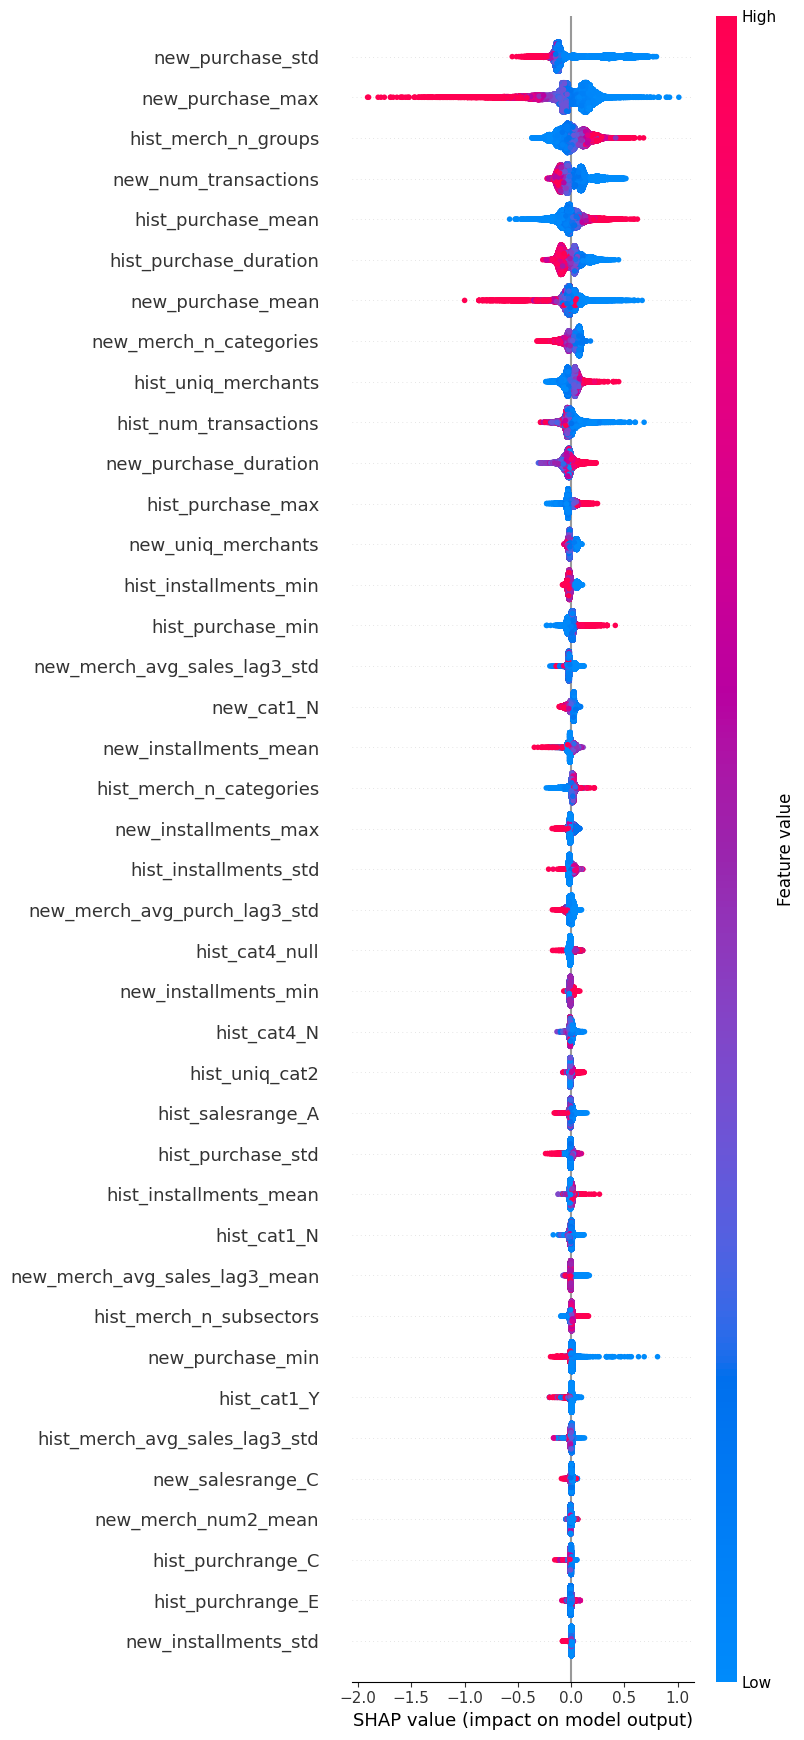

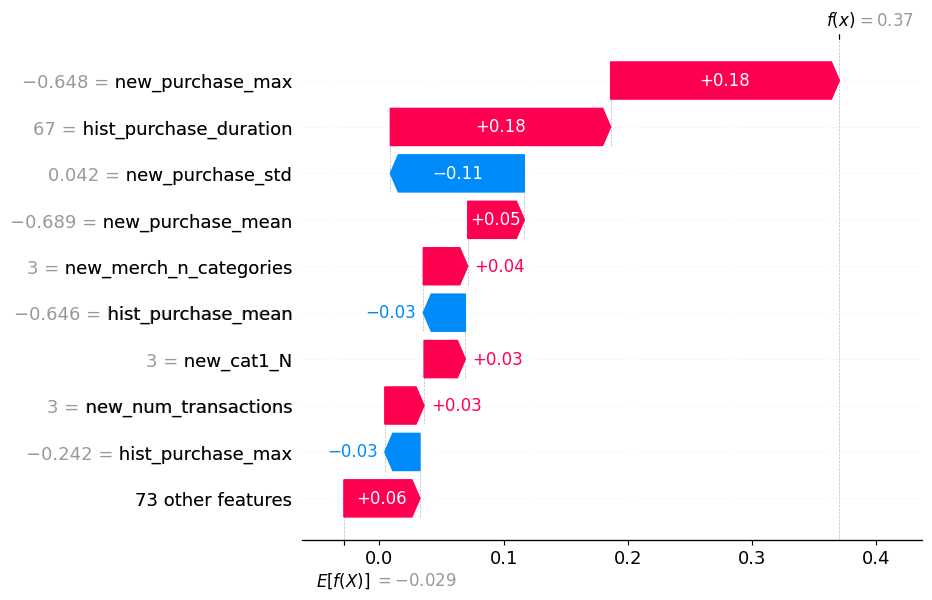

In [191]:
import shap

# Entrena tu modelo final (si no lo has hecho ya)
# model.fit(X_train, y_train, ...)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

# Summary plot (global)
shap.summary_plot(shap_values, X_val, max_display=40)

# Ejemplo de explicación individual (primer registro)
shap.force_plot(explainer.expected_value, shap_values[0], X_val.iloc[0])

shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                      base_values=explainer.expected_value,
                                      data=X_val.iloc[0]))



1. Principales factores que determinan la lealtad
El análisis de importancia global utilizando SHAP revela que los factores más determinantes para predecir el score de lealtad son:

Comportamiento reciente: Variables derivadas de compras recientes en nuevos comercios, como el monto máximo de compra (new_purchase_max), el promedio de compras recientes (new_purchase_mean) y la cantidad de transacciones en nuevos comercios (new_num_transactions), se ubican consistentemente entre las de mayor impacto. Esto sugiere que la actividad actual del usuario es altamente predictiva de su nivel de lealtad.

Historial transaccional: Características agregadas del historial de transacciones, como la media y la duración del historial (hist_purchase_mean, hist_purchase_duration), también son relevantes. Esto indica que no solo importa lo que el usuario hace recientemente, sino también la consistencia y el alcance de su comportamiento histórico.

Diversidad de interacción: El número de grupos y categorías de merchants visitados (por ejemplo, hist_merch_n_groups, new_merch_n_categories) incrementa el score de lealtad. Los clientes que interactúan con una mayor variedad de comercios tienden a mostrar mayor compromiso con el programa.

2. Influencia de los valores altos y bajos
La visualización SHAP muestra que:

Valores altos de montos recientes y diversidad de merchants (en rojo) tienden a incrementar el score de lealtad predicho.

Por el contrario, valores bajos o poca variabilidad en las compras recientes suelen asociarse con menores niveles de lealtad.

Algunos factores, como la desviación estándar de montos de compra, tienen un efecto mixto, dependiendo del contexto específico de cada cliente.

3. Interpretabilidad individual y confianza en el modelo
El análisis individual de predicciones mediante gráficos tipo “waterfall” permite desglosar cómo cada variable influye en el resultado para un usuario específico. Por ejemplo, para un cliente concreto, un historial de compras extenso junto con montos altos en nuevos comercios explica un score de lealtad elevado. Este nivel de detalle permite brindar explicaciones transparentes y personalizadas a los usuarios de negocio.

4. Valor para la toma de decisiones
Gracias a la interpretabilidad del modelo, los equipos comerciales y de marketing pueden identificar fácilmente qué acciones o segmentos priorizar. Por ejemplo, se pueden diseñar campañas dirigidas a clientes con alta actividad reciente en nuevos comercios, o enfocar incentivos en aquellos con potencial de diversificar su consumo.

Conclusión del análisis interpretativo
El uso de SHAP no solo permite evaluar la calidad predictiva del modelo, sino también brindar confianza y capacidad de acción a usuarios no técnicos. El enfoque interpretativo asegura que el modelo pueda ser utilizado como herramienta de apoyo real en la gestión de la lealtad de los clientes.

In [ ]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [ ]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()

In [143]:
len(X_train.columns)

82

In [140]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Supongamos que ya tienes tus datos
# X, y = tus features y target

# Entrena modelo base para obtener la importancia de features
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_base = LGBMRegressor(random_state=42)
modelo_base.fit(X_train, y_train)
importancias = pd.Series(modelo_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Número de features a probar
top_n_list = [10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

resultados = []

for top_n in top_n_list:
    top_features = importancias.index[:top_n]
    print(f"\nProbando con las top {top_n} features: {list(top_features)}")
    
    # Subset de datos
    X_train_sub = X_train[top_features]
    X_val_sub = X_val[top_features]
    
    # Entrena un modelo nuevo solo con esas features
    modelo = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
    modelo.fit(X_train_sub, y_train)
    
    # Predicción y RMSE
    y_pred = modelo.predict(X_val_sub)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    resultados.append((top_n, rmse))
    print(f"RMSE validación (top {top_n}): {rmse:.5f}")

# Mostrar resumen final
print("\n--- Resultados finales ---")
for n, score in resultados:
    print(f"Top {n} features: RMSE = {score:.5f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022848 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11464
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 80
[LightGBM] [Info] Start training from score -0.028637

Probando con las top 10 features: ['hist_purchase_mean', 'new_purchase_max', 'hist_purchase_duration', 'new_purchase_mean', 'hist_merch_n_groups', 'hist_num_transactions', 'hist_purchase_min', 'new_purchase_duration', 'hist_purchase_max', 'hist_uniq_merchants']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001838 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2277
[LightGBM] [Info] Number of data points in the train set: 159768, number of used features: 10
[LightGBM] [Info] Start training from score -0.028637
RMSE validación (top 10): 1.57330

Probando con 

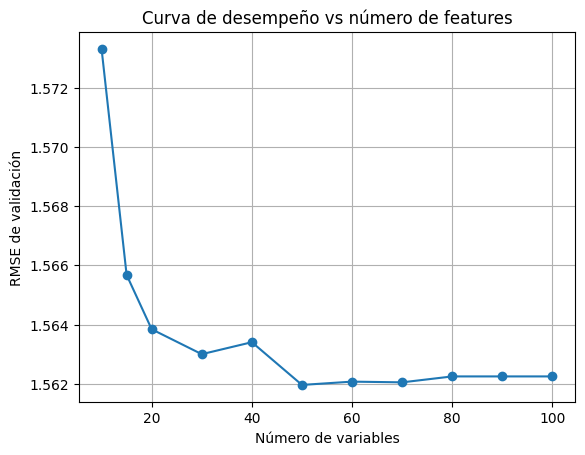

In [141]:
import matplotlib.pyplot as plt

n_features = [x[0] for x in resultados]
rmse_scores = [x[1] for x in resultados]

plt.plot(n_features, rmse_scores, marker='o')
plt.xlabel('Número de variables')
plt.ylabel('RMSE de validación')
plt.title('Curva de desempeño vs número de features')
plt.grid()
plt.show()


In [138]:
df_final.write_parquet("src/train_processed_final_v5.parquet")

In [1]:
import polars as pl

In [155]:
df_final = pl.read_parquet("src/train_processed_final_v5.parquet")

In [154]:
df_final.schema

Schema([('first_active_month', Date),
        ('card_id', String),
        ('target', Float64),
        ('hist_purchase_mean', Float64),
        ('hist_purchase_std', Float64),
        ('hist_purchase_min', Float64),
        ('hist_purchase_max', Float64),
        ('hist_installments_mean', Float64),
        ('hist_installments_std', Float64),
        ('hist_installments_min', Int64),
        ('hist_installments_max', Int64),
        ('hist_num_transactions', UInt32),
        ('hist_first_purchase', Datetime(time_unit='us', time_zone=None)),
        ('hist_last_purchase', Datetime(time_unit='us', time_zone=None)),
        ('hist_uniq_merchants', UInt32),
        ('hist_uniq_cat1', UInt32),
        ('hist_uniq_cat2', UInt32),
        ('hist_uniq_cat3', UInt32),
        ('hist_purchase_duration', Int64),
        ('hist_merch_avg_sales_lag3_mean', Float64),
        ('hist_merch_avg_sales_lag3_std', Float64),
        ('hist_merch_avg_purch_lag3_mean', Float64),
        ('hist_merch_avg_pur

In [153]:
df_final.limit(5)

first_active_month,card_id,target,hist_purchase_mean,hist_purchase_std,hist_purchase_min,hist_purchase_max,hist_installments_mean,hist_installments_std,hist_installments_min,hist_installments_max,hist_num_transactions,hist_first_purchase,hist_last_purchase,hist_uniq_merchants,hist_uniq_cat1,hist_uniq_cat2,hist_uniq_cat3,hist_purchase_duration,hist_merch_avg_sales_lag3_mean,hist_merch_avg_sales_lag3_std,hist_merch_avg_purch_lag3_mean,hist_merch_avg_purch_lag3_std,hist_merch_n_categories,hist_merch_n_groups,hist_merch_n_subsectors,hist_merch_num1_mean,hist_merch_num2_mean,hist_cat1_Y,hist_cat1_N,hist_cat1_null,hist_cat4_Y,hist_cat4_N,hist_cat4_null,hist_salesrange_A,hist_salesrange_B,hist_salesrange_C,hist_salesrange_D,hist_salesrange_E,hist_salesrange_null,hist_purchrange_A,hist_purchrange_B,hist_purchrange_C,hist_purchrange_D,hist_purchrange_E,hist_purchrange_null,new_purchase_mean,new_purchase_std,new_purchase_min,new_purchase_max,new_installments_mean,new_installments_std,new_installments_min,new_installments_max,new_num_transactions,new_first_purchase,new_last_purchase,new_uniq_merchants,new_uniq_cat1,new_uniq_cat2,new_uniq_cat3,new_purchase_duration,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_cat1_Y,new_cat1_N,new_cat1_null,new_cat4_Y,new_cat4_N,new_cat4_null,new_salesrange_A,new_salesrange_B,new_salesrange_C,new_salesrange_D,new_salesrange_E,new_salesrange_null,new_purchrange_A,new_purchrange_B,new_purchrange_C,new_purchrange_D,new_purchrange_E,new_purchrange_null
date,str,f64,f64,f64,f64,f64,f64,f64,i64,i64,u32,datetime[μs],datetime[μs],u32,u32,u32,u32,i64,f64,f64,f64,f64,u32,u32,u32,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,u32,datetime[μs],datetime[μs],u32,u32,u32,u32,i64,f64,f64,f64,f64,u32,u32,u32,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
2017-06-01,"""C_ID_92a2005557""",-0.820283,-0.638341,0.212139,-0.739395,2.258395,0.015385,0.123314,0,1,260,2017-06-27 14:18:08,2018-02-25 09:31:15,95,1,2,2,242,1.260502,1.07157,1.554389,2.187587,41,74,21,15.652829,15.077305,0,265,0,247,12,6,69,44,72,57,17,6,83,59,63,35,19,6,-0.575835,0.135812,-0.724368,-0.296112,0.0,0.0,0,0,23,2018-03-05 14:04:36,2018-04-29 11:23:05,23,1,1,1,54,1.100435,0.424944,1.087348,0.2634,14,17,10,27.554676,27.221018,0,23,0,19,4,0,7,1,7,5,3,0,7,1,5,7,3,0
2017-01-01,"""C_ID_3d0044924f""",0.392913,-0.600018,0.384967,-0.7424,4.6302994,1.551429,1.510777,-1,10,350,2017-01-06 16:29:42,2018-01-31 22:31:09,142,2,2,3,390,1.223507,1.073557,1.403744,1.915783,57,103,24,27.275476,26.705192,35,330,0,336,29,0,195,53,37,55,25,0,200,40,58,35,32,0,-0.725956,0.014326,-0.73941,-0.701858,1.0,0.0,1,1,6,2018-02-01 17:07:54,2018-03-30 06:48:26,6,1,1,1,56,1.013333,0.080664,0.959852,0.110758,5,6,4,0.545686,0.537424,0,6,0,6,0,0,1,2,0,3,0,0,1,2,3,0,0,0
2016-08-01,"""C_ID_d639edf6cd""",0.688056,-0.678311,0.08738,-0.730138,-0.145847,0.0,0.0,0,0,43,2017-01-11 08:21:22,2018-02-27 19:08:25,13,1,2,1,412,1.137045,0.894221,1.288019,1.7617,8,9,7,1.222453,1.047591,0,44,0,41,3,0,36,4,2,0,2,0,37,3,1,1,2,0,-0.700326,0.0,-0.700326,-0.700326,0.0,0.0,0,0,1,2018-04-28 17:43:11,2018-04-28 17:43:11,1,1,1,1,0,1.33,0.0,1.297775,0.0,1,1,1,-0.027726,-0.037641,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
2017-09-01,"""C_ID_186d6a6901""",0.1424952,-0.642745,0.261624,-0.740897,1.445596,1.090909,0.588974,-1,3,77,2017-09-26 16:22:21,2018-02-28 11:44:40,50,2,3,3,154,1.609326,1.800569,2.211761,3.542116,25,39,13,4.123834,4.038387,13,76,0,87,2,0,38,7,15,10,19,0,37,9,15,9,19,0,-0.66491,0.065882,-0.734135,-0.56674,0.714286,0.755929,-1,1,7,2018-03-07 11:55:06,2018-04-18 11:00:11,7,2,2,2,41,1.074286,0.216938,1.052051,0.169877,6,5,5,0.140827,0.135162,1,6,0,7,0,0,0,1,1,5,0,0,0,1,2,4,0,0
2017-11-01,"""C_ID_cdbd2c0db2""",-0.159749,-0.366073,1.352094,

In [156]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()


In [180]:
df_final_pd = df_final.to_pandas()

In [181]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from lightgbm import early_stopping as lgb_early_stopping

# Supongamos que tu df_final ya está en pandas (convierte de polars si es necesario)
# Selecciona features y target
# X = df_final[good_features]
# y = df_final["target"]

# Primero: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Segundo: divide el 30% restante en val y test (cada uno será 15% del total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

# Opcional: agrega columna al DataFrame para marcar split
df_final_pd['data_split'] = 'train'
df_final_pd.loc[X_val.index, 'data_split'] = 'val'
df_final_pd.loc[X_test.index, 'data_split'] = 'test'

# Entrena LightGBM usando validación
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb_early_stopping(stopping_rounds=30)]
)

# Predicción para agregar columna
df_final_pd['lgbm_pred'] = lgbm.predict(X)

# Ahora tienes: target, prediction, cluster, data_split, y todas tus features


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11433
[LightGBM] [Info] Number of data points in the train set: 139797, number of used features: 80
[LightGBM] [Info] Start training from score -0.028940
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[213]	valid_0's l2: 2.47308


In [164]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 6. Calcula métricas por split ---
for split in ['train', 'val', 'test']:
    idx = df_final_pd['data_split'] == split
    y_true = df_final_pd.loc[idx, 'target']
    y_pred = df_final_pd.loc[idx, 'prediction']
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{split.upper()} -> RMSE: {rmse:.5f}, MAE: {mae:.5f}, R2: {r2:.5f}")


TRAIN -> RMSE: 1.53740, MAE: 1.09329, R2: 0.20287
VAL -> RMSE: 1.57260, MAE: 1.11195, R2: 0.15703
TEST -> RMSE: 1.56618, MAE: 1.11302, R2: 0.15422


“El modelo logra explicar aproximadamente el 15–20% de la varianza del score de lealtad, con un error medio estable y consistente entre los conjuntos de entrenamiento, validación y prueba. Esto indica un desempeño robusto ante datos nuevos, aunque existe un margen para incrementar el poder predictivo mediante la incorporación de nuevas variables o técnicas.”

In [182]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Suponiendo que tienes X (features) e y (target)
# X = df_final[good_features]
# y = df_final["target"]

# 1. División de datos
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y, test_size=0.3, random_state=42)

# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42)

# 2. Entrenamiento del modelo CatBoost
catb = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    random_state=42,
    verbose=50,
    early_stopping_rounds=30
)

catb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

# 3. Predicciones
train_pred = catb.predict(X_train)
val_pred = catb.predict(X_val)
test_pred = catb.predict(X_test)

df_final_pd['cat_pred'] = catb.predict(df_final_pd[good_features])

# 4. Métricas
def metrics(y_true, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.5f}, MAE: {mae:.5f}, R2: {r2:.5f}")

metrics(y_train, train_pred, "TRAIN")
metrics(y_val, val_pred, "VAL")
metrics(y_test, test_pred, "TEST")


0:	learn: 1.7136244	test: 1.7046154	best: 1.7046154 (0)	total: 30.1ms	remaining: 15s
50:	learn: 1.6067249	test: 1.5989496	best: 1.5989496 (50)	total: 625ms	remaining: 5.51s
100:	learn: 1.5917343	test: 1.5862608	best: 1.5862608 (100)	total: 1.21s	remaining: 4.77s
150:	learn: 1.5837590	test: 1.5804130	best: 1.5804130 (150)	total: 1.79s	remaining: 4.14s
200:	learn: 1.5781894	test: 1.5772714	best: 1.5772714 (200)	total: 2.39s	remaining: 3.56s
250:	learn: 1.5735212	test: 1.5748321	best: 1.5748321 (250)	total: 2.95s	remaining: 2.92s
300:	learn: 1.5686264	test: 1.5731526	best: 1.5731526 (300)	total: 3.5s	remaining: 2.31s
350:	learn: 1.5642956	test: 1.5718464	best: 1.5718464 (350)	total: 4.08s	remaining: 1.73s
400:	learn: 1.5608720	test: 1.5712114	best: 1.5712114 (400)	total: 4.63s	remaining: 1.14s
450:	learn: 1.5572809	test: 1.5707454	best: 1.5707454 (450)	total: 5.22s	remaining: 567ms
499:	learn: 1.5539263	test: 1.5702088	best: 1.5701850 (494)	total: 5.79s	remaining: 0us

bestTest = 1.570184

In [177]:
df_final_pd

,first_active_month,card_id,target,hist_purchase_mean,hist_purchase_std,hist_purchase_min,hist_purchase_max,hist_installments_mean,hist_installments_std,hist_installments_min,hist_installments_max,hist_num_transactions,hist_first_purchase,hist_last_purchase,hist_uniq_merchants,hist_uniq_cat1,hist_uniq_cat2,hist_uniq_cat3,hist_purchase_duration,hist_merch_avg_sales_lag3_mean,hist_merch_avg_sales_lag3_std,hist_merch_avg_purch_lag3_mean,hist_merch_avg_purch_lag3_std,hist_merch_n_categories,hist_merch_n_groups,hist_merch_n_subsectors,hist_merch_num1_mean,hist_merch_num2_mean,hist_cat1_Y,hist_cat1_N,hist_cat1_null,hist_cat4_Y,hist_cat4_N,hist_cat4_null,hist_salesrange_A,hist_salesrange_B,hist_salesrange_C,hist_salesrange_D,hist_salesrange_E,hist_salesrange_null,...,new_installments_min,new_installments_max,new_num_transactions,new_first_purchase,new_last_purchase,new_uniq_merchants,new_uniq_cat1,new_uniq_cat2,new_uniq_cat3,new_purchase_duration,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_cat1_Y,new_cat1_N,new_cat1_null,new_cat4_Y,new_cat4_N,new_cat4_null,new_salesrange_A,new_salesrange_B,new_salesrange_C,new_salesrange_D,new_salesrange_E,new_salesrange_null,new_purchrange_A,new_purchrange_B,new_purchrange_C,new_purchrange_D,new_purchrange_E,new_purchrange_null,data_split,prediction,xgb_pred
0,2017-06-01,C_ID_92a2005557,-0.820283,-0.638341,0.212139,-0.739395,2.258395,0.015385,0.123314,0,1,260,2017-06-27 14:18:08,2018-02-25 09:31:15,95,1,2,2,242,1.260502,1.071570,1.554389,2.187587,41,74,21,15.652829,15.077305,0,265,0,247,12,6,69,44,72,57,17,6,...,0,0,23,2018-03-05 14:04:36,2018-04-29 11:23:05,23,1,1,1,54,1.100435,0.424944,1.087348,0.263400,14,17,10,27.554676,27.221018,0,23,0,19,4,0,7,1,7,5,3,0,7,1,5,7,3,0,test,-0.382595,-0.413541
1,2017-01-01,C_ID_3d0044924f,0.392913,-0.600018,0.384967,-0.742400,4.630299,1.551429,1.510777,-1,10,350,2017-01-06 16:29:42,2018-01-31 22:31:09,142,2,2,3,390,1.223507,1.073557,1.403744,1.915783,57,103,24,27.275476,26.705192,35,330,0,336,29,0,195,53,37,55,25,0,...,1,1,6,2018-02-01 17:07:54,2018-03-30 06:48:26,6,1,1,1,56,1.013333,0.080664,0.959852,0.110758,5,6,4,0.545686,0.537424,0,6,0,6,0,0,1,2,0,3,0,0,1,2,3,0,0,0,train,0.284759,0.425032
2,2016-08-01,C_ID_d639edf6cd,0.688056,-0.678311,0.087380,-0.730138,-0.145847,0.000000,0.000000,0,0,43,2017-01-11 08:21:22,2018-02-27 19:08:25,13,1,2,1,412,1.137045,0.894221,1.288019,1.761700,8,9,7,1.222453,1.047591,0,44,0,41,3,0,36,4,2,0,2,0,...,0,0,1,2018-04-28 17:43:11,2018-04-28 17:43:11,1,1,1,1,0,1.330000,0.000000,1.297775,0.000000,1,1,1,-0.027726,-0.037641,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,train,0.534345,0.470926
3,2017-09-01,C_ID_186d6a6901,0.142495,-0.642745,0.261624,-0.740897,1.445596,1.090909,0.588974,-1,3,77,2017-09-26 16:22:21,2018-02-28 11:44:40,50,2,3,3,154,1.609326,1.800569,2.211761,3.542116,25,39,13,4.123834,4.038387,13,76,0,87,2,0,38,7,15,10,19,0,...,-1,1,7,2018-03-07 11:55:06,2018-04-18 11:00:11,7,2,2,2,41,1.074286,0.216938,1.052051,0.169877,6,5,5,0.140827,0.135162,1,6,0,7,0,0,0,1,1,5,0,0,0,1,2,4,0,0,train,-0.006314,0.100630
4,2017-11-01,C_ID_cdbd2c0db2,-0.159749,-0.366073,1.352094,-0.746156,7.193041,1.368421,1.896862,1,12,133,2017-11-12 00:00:00,2018-02-28 20:40:41,67,2,4,2,108,1.415745,1.401889,1.799667,2.779000,26,53,17,3.224011,3.172819,16,126,0,134,7,1,44,6,25,49,17,1,...,-1,2,36,2018-03-02 11:55:43,2018-04-28 18:50:25,36,2,4,3,57,6.123333,30.748869,2.022700,6.016232,17,30,10,1.423981,1.387351,2,34,0,26,10,0,7,3,10,13,3,0,7,4,9,10,6,0,val,-0.232840,-0.331702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [148]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Si tienes pandas DataFrames:
# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
# X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
# X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)

model_cb = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    random_state=42,
    verbose=50,  # muestra progreso cada 50 iteraciones
    early_stopping_rounds=30
)
model_cb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred_cb = model_cb.predict(X_val)
rmse_cb = np.sqrt(mean_squared_error(y_val, y_pred_cb))
print(f"CatBoost RMSE validación: {rmse_cb:.5f}")


0:	learn: 1.7130020	test: 1.6938265	best: 1.6938265 (0)	total: 16.1ms	remaining: 8.01s
50:	learn: 1.6069128	test: 1.5881928	best: 1.5881928 (50)	total: 651ms	remaining: 5.73s
100:	learn: 1.5916647	test: 1.5753307	best: 1.5753307 (100)	total: 1.27s	remaining: 5.02s
150:	learn: 1.5841528	test: 1.5697583	best: 1.5697583 (150)	total: 1.89s	remaining: 4.36s
200:	learn: 1.5789366	test: 1.5664286	best: 1.5664286 (200)	total: 2.5s	remaining: 3.72s
250:	learn: 1.5747498	test: 1.5642843	best: 1.5642843 (250)	total: 3.09s	remaining: 3.06s
300:	learn: 1.5704460	test: 1.5628917	best: 1.5628917 (300)	total: 3.7s	remaining: 2.44s
350:	learn: 1.5662946	test: 1.5619315	best: 1.5619315 (350)	total: 4.3s	remaining: 1.82s
400:	learn: 1.5628042	test: 1.5615731	best: 1.5615465 (397)	total: 4.89s	remaining: 1.21s
450:	learn: 1.5596017	test: 1.5610965	best: 1.5610965 (450)	total: 5.5s	remaining: 598ms
499:	learn: 1.5568742	test: 1.5608074	best: 1.5607758 (493)	total: 6.07s	remaining: 0us

bestTest = 1.5607758

In [1]:
import polars as pl

In [15]:
df_final = pl.read_parquet("src/train_processed_final_v4.parquet")

In [5]:
len(df_final.columns)

108

In [10]:
print(df_final.limit(1))

shape: (1, 108)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬──

In [150]:
df_final.drop(['first_active_month_right', 'card_id_right', 'target_right']).write_parquet("src/train_processed_final_v5.parquet")

In [17]:
df_final_pandas = df_final.to_pandas()

In [19]:
# Para mostrar el DataFrame en formato vertical (registro por registro) en Polars:
print(df_final_pandas.iloc[0].to_frame())

                                       0
first_active_month   2017-06-01 00:00:00
card_id                  C_ID_92a2005557
target                         -0.820283
hist_purchase_mean             -0.638341
hist_purchase_std               0.212139
...                                  ...
new_purchrange_B                       0
new_purchrange_C                       0
new_purchrange_D                       0
new_purchrange_E                       0
new_purchrange_null                    0

[108 rows x 1 columns]


In [ ]:
import polars as pl

# Definir tipos numéricos válidos en Polars
numeric_types = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

exclude_cols = ["card_id", "target", "first_active_month", "target", "target_right"]  # ajusta si tienes más
good_features = [
    col for col, dtype in df_final.schema.items()
    if dtype in numeric_types and col not in exclude_cols
]

X = df_final.select(good_features).to_pandas()
y = df_final["target"].to_pandas()


In [183]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Asumiendo que tienes X (features), y (target) y df_final_pd (DataFrame original)
# Si tu DataFrame está en Polars, primero conviértelo a pandas:
# df_final_pd = df_final.to_pandas()

# 1. División 70/15/15
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y, test_size=0.3, random_state=42
# )
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42
# )



# # 2. Marca splits en el DataFrame
# df_final_pd['data_split'] = 'train'
# df_final_pd.loc[X_val.index, 'data_split'] = 'val'
# df_final_pd.loc[X_test.index, 'data_split'] = 'test'


X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)
# X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)


# 3. Instancia y entrena el modelo XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    verbosity=1
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    # early_stopping_rounds=30,
    verbose=50
)

# 4. Predicción (para todo el DataFrame)
df_final_pd['xgb_pred'] = xgb.predict(df_final_pd[good_features])

# 5. Métricas por conjunto
def metrics(y_true, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.5f}, MAE: {mae:.5f}, R2: {r2:.5f}")

metrics(y_train, train_pred, "TRAIN")
metrics(y_val, val_pred, "VAL")
metrics(y_test, test_pred, "TEST")



[0]	validation_0-rmse:1.70287
[50]	validation_0-rmse:1.58376
[100]	validation_0-rmse:1.57531
[150]	validation_0-rmse:1.57327
[200]	validation_0-rmse:1.57296
[250]	validation_0-rmse:1.57314
[300]	validation_0-rmse:1.57365
[350]	validation_0-rmse:1.57388
[400]	validation_0-rmse:1.57394
[450]	validation_0-rmse:1.57462
[499]	validation_0-rmse:1.57502
TRAIN -> RMSE: 1.55426, MAE: 1.10384, R2: 0.18530
VAL -> RMSE: 1.57018, MAE: 1.11028, R2: 0.15962
TEST -> RMSE: 1.56408, MAE: 1.11237, R2: 0.15649


In [184]:
df_final_pd

,first_active_month,card_id,target,hist_purchase_mean,hist_purchase_std,hist_purchase_min,hist_purchase_max,hist_installments_mean,hist_installments_std,hist_installments_min,hist_installments_max,hist_num_transactions,hist_first_purchase,hist_last_purchase,hist_uniq_merchants,hist_uniq_cat1,hist_uniq_cat2,hist_uniq_cat3,hist_purchase_duration,hist_merch_avg_sales_lag3_mean,hist_merch_avg_sales_lag3_std,hist_merch_avg_purch_lag3_mean,hist_merch_avg_purch_lag3_std,hist_merch_n_categories,hist_merch_n_groups,hist_merch_n_subsectors,hist_merch_num1_mean,hist_merch_num2_mean,hist_cat1_Y,hist_cat1_N,hist_cat1_null,hist_cat4_Y,hist_cat4_N,hist_cat4_null,hist_salesrange_A,hist_salesrange_B,hist_salesrange_C,hist_salesrange_D,hist_salesrange_E,hist_salesrange_null,...,new_installments_max,new_num_transactions,new_first_purchase,new_last_purchase,new_uniq_merchants,new_uniq_cat1,new_uniq_cat2,new_uniq_cat3,new_purchase_duration,new_merch_avg_sales_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_mean,new_merch_avg_purch_lag3_std,new_merch_n_categories,new_merch_n_groups,new_merch_n_subsectors,new_merch_num1_mean,new_merch_num2_mean,new_cat1_Y,new_cat1_N,new_cat1_null,new_cat4_Y,new_cat4_N,new_cat4_null,new_salesrange_A,new_salesrange_B,new_salesrange_C,new_salesrange_D,new_salesrange_E,new_salesrange_null,new_purchrange_A,new_purchrange_B,new_purchrange_C,new_purchrange_D,new_purchrange_E,new_purchrange_null,data_split,lgbm_pred,cat_pred,xgb_pred
0,2017-06-01,C_ID_92a2005557,-0.820283,-0.638341,0.212139,-0.739395,2.258395,0.015385,0.123314,0,1,260,2017-06-27 14:18:08,2018-02-25 09:31:15,95,1,2,2,242,1.260502,1.071570,1.554389,2.187587,41,74,21,15.652829,15.077305,0,265,0,247,12,6,69,44,72,57,17,6,...,0,23,2018-03-05 14:04:36,2018-04-29 11:23:05,23,1,1,1,54,1.100435,0.424944,1.087348,0.263400,14,17,10,27.554676,27.221018,0,23,0,19,4,0,7,1,7,5,3,0,7,1,5,7,3,0,test,-0.382868,-0.413541,-0.483772
1,2017-01-01,C_ID_3d0044924f,0.392913,-0.600018,0.384967,-0.742400,4.630299,1.551429,1.510777,-1,10,350,2017-01-06 16:29:42,2018-01-31 22:31:09,142,2,2,3,390,1.223507,1.073557,1.403744,1.915783,57,103,24,27.275476,26.705192,35,330,0,336,29,0,195,53,37,55,25,0,...,1,6,2018-02-01 17:07:54,2018-03-30 06:48:26,6,1,1,1,56,1.013333,0.080664,0.959852,0.110758,5,6,4,0.545686,0.537424,0,6,0,6,0,0,1,2,0,3,0,0,1,2,3,0,0,0,train,0.284476,0.425032,0.471719
2,2016-08-01,C_ID_d639edf6cd,0.688056,-0.678311,0.087380,-0.730138,-0.145847,0.000000,0.000000,0,0,43,2017-01-11 08:21:22,2018-02-27 19:08:25,13,1,2,1,412,1.137045,0.894221,1.288019,1.761700,8,9,7,1.222453,1.047591,0,44,0,41,3,0,36,4,2,0,2,0,...,0,1,2018-04-28 17:43:11,2018-04-28 17:43:11,1,1,1,1,0,1.330000,0.000000,1.297775,0.000000,1,1,1,-0.027726,-0.037641,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,train,0.534329,0.470926,0.313652
3,2017-09-01,C_ID_186d6a6901,0.142495,-0.642745,0.261624,-0.740897,1.445596,1.090909,0.588974,-1,3,77,2017-09-26 16:22:21,2018-02-28 11:44:40,50,2,3,3,154,1.609326,1.800569,2.211761,3.542116,25,39,13,4.123834,4.038387,13,76,0,87,2,0,38,7,15,10,19,0,...,1,7,2018-03-07 11:55:06,2018-04-18 11:00:11,7,2,2,2,41,1.074286,0.216938,1.052051,0.169877,6,5,5,0.140827,0.135162,1,6,0,7,0,0,0,1,1,5,0,0,0,1,2,4,0,0,train,-0.006115,0.100630,0.079867
4,2017-11-01,C_ID_cdbd2c0db2,-0.159749,-0.366073,1.352094,-0.746156,7.193041,1.368421,1.896862,1,12,133,2017-11-12 00:00:00,2018-02-28 20:40:41,67,2,4,2,108,1.415745,1.401889,1.799667,2.779000,26,53,17,3.224011,3.172819,16,126,0,134,7,1,44,6,25,49,17,1,...,2,36,2018-03-02 11:55:43,2018-04-28 18:50:25,36,2,4,3,57,6.123333,30.748869,2.022700,6.016232,17,30,10,1.423981,1.387351,2,34,0,26,10,0,7,3,10,13,3,0,7,4,9,10,6,0,val,-0.232633,-0.331702,-0.150651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [185]:
df_final_pd.to_parquet("src/train_processed_final_predicted.parquet")

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split train/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_val = X_val.replace([np.inf, -np.inf], np.nan).fillna(0)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    verbosity=1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    # early_stopping_rounds=30,
    verbose=True
)

y_pred_xgb = model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
print(f"XGBoost RMSE validación: {rmse_xgb:.5f}")


[0]	validation_0-rmse:1.69232
[1]	validation_0-rmse:1.68312
[2]	validation_0-rmse:1.67464
[3]	validation_0-rmse:1.66696
[4]	validation_0-rmse:1.65975
[5]	validation_0-rmse:1.65337
[6]	validation_0-rmse:1.64733
[7]	validation_0-rmse:1.64199
[8]	validation_0-rmse:1.63684
[9]	validation_0-rmse:1.63243
[10]	validation_0-rmse:1.62821
[11]	validation_0-rmse:1.62450
[12]	validation_0-rmse:1.62085
[13]	validation_0-rmse:1.61767
[14]	validation_0-rmse:1.61475
[15]	validation_0-rmse:1.61205
[16]	validation_0-rmse:1.60950
[17]	validation_0-rmse:1.60690
[18]	validation_0-rmse:1.60478
[19]	validation_0-rmse:1.60271
[20]	validation_0-rmse:1.60063
[21]	validation_0-rmse:1.59870
[22]	validation_0-rmse:1.59691
[23]	validation_0-rmse:1.59536
[24]	validation_0-rmse:1.59399
[25]	validation_0-rmse:1.59256
[26]	validation_0-rmse:1.59095
[27]	validation_0-rmse:1.58975
[28]	validation_0-rmse:1.58862
[29]	validation_0-rmse:1.58752
[30]	validation_0-rmse:1.58652
[31]	validation_0-rmse:1.58551
[32]	validation_0-

In [202]:
df_final = pl.read_parquet("src/train_processed_final_predicted.parquet")

In [203]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Suponiendo que tu df_final ya está en pandas (sino convierte desde Polars)
features_clustering = [
    "new_purchase_std",
    "new_purchase_max",
    "hist_merch_n_groups",
    "new_num_transactions",
    "hist_purchase_mean",
    "hist_purchase_duration",
    "new_purchase_mean",
    "new_merch_n_categories",
    "hist_uniq_merchants",
    "hist_num_transactions",
    "new_purchase_duration",
    "hist_purchase_max",
    "hist_purchase_std",
    "new_purchase_min",
    "hist_installments_std",
    "new_installments_mean",
    "hist_merch_n_categories",
    "hist_installments_mean",
    "hist_cat1_N",
    "hist_cat4_N",
    "hist_merch_avg_sales_lag3_mean",
    "hist_salesrange_A",
    "hist_merch_avg_purch_lag3_mean",
    "hist_purchrange_C",
    "hist_merch_avg_sales_lag3_std",
    "hist_merch_avg_purch_lag3_std",
    "new_merch_avg_sales_lag3_mean",
    "new_merch_avg_purch_lag3_mean",
    "new_merch_avg_sales_lag3_std",
    "new_merch_avg_purch_lag3_std",
    "hist_merch_n_subsectors"
]

df_final_pd = df_final.select(features_clustering).to_pandas().replace([np.inf, -np.inf], np.nan).fillna(0)  # Asegúrate de que df_final sea un DataFrame de pandas

X_clust = df_final_pd[features_clustering].fillna(0).copy() #  O el método que prefieras para nulos

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)


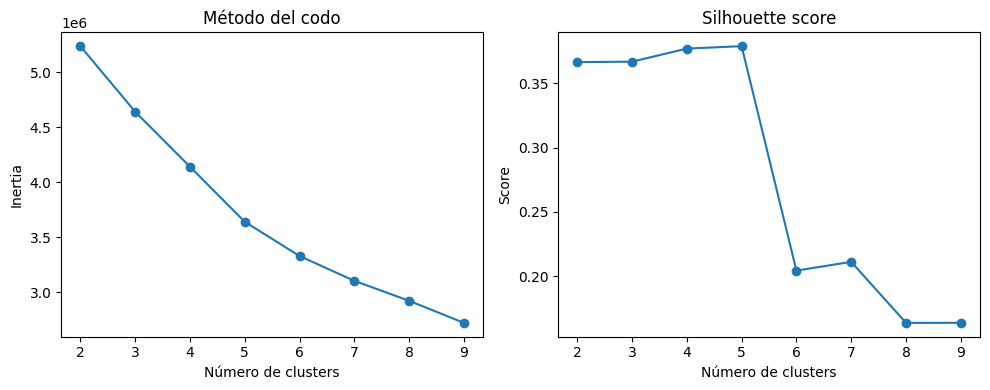

In [204]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(K, silhouette, marker='o')
plt.title('Silhouette score')
plt.xlabel('Número de clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


In [215]:
df_final = pl.read_parquet("src/train_processed_final_predicted.parquet")

In [206]:
df_final.schema

Schema([('first_active_month', Datetime(time_unit='ms', time_zone=None)),
        ('card_id', String),
        ('target', Float64),
        ('hist_purchase_mean', Float64),
        ('hist_purchase_std', Float64),
        ('hist_purchase_min', Float64),
        ('hist_purchase_max', Float64),
        ('hist_installments_mean', Float64),
        ('hist_installments_std', Float64),
        ('hist_installments_min', Int64),
        ('hist_installments_max', Int64),
        ('hist_num_transactions', UInt32),
        ('hist_first_purchase', Datetime(time_unit='us', time_zone=None)),
        ('hist_last_purchase', Datetime(time_unit='us', time_zone=None)),
        ('hist_uniq_merchants', UInt32),
        ('hist_uniq_cat1', UInt32),
        ('hist_uniq_cat2', UInt32),
        ('hist_uniq_cat3', UInt32),
        ('hist_purchase_duration', Int64),
        ('hist_merch_avg_sales_lag3_mean', Float64),
        ('hist_merch_avg_sales_lag3_std', Float64),
        ('hist_merch_avg_purch_lag3_mean', Fl

In [207]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Suponiendo que tu df_final ya está en pandas (sino convierte desde Polars)
features_final = [
    "new_purchase_std",
    "new_purchase_max",
    "hist_merch_n_groups",
    "new_num_transactions",
    "hist_purchase_mean",
    "hist_purchase_duration",
    "new_purchase_mean",
    "new_merch_n_categories",
    "hist_uniq_merchants",
    "hist_num_transactions",
    "new_purchase_duration",
    "hist_purchase_max",
    "hist_purchase_std",
    "new_purchase_min",
    "hist_installments_std",
    "new_installments_mean",
    "hist_merch_n_categories",
    "hist_installments_mean",
    "hist_cat1_N",
    "hist_cat4_N",
    "hist_merch_avg_sales_lag3_mean",
    "hist_salesrange_A",
    "hist_merch_avg_purch_lag3_mean",
    "hist_purchrange_C",
    "hist_merch_avg_sales_lag3_std",
    "hist_merch_avg_purch_lag3_std",
    "new_merch_avg_sales_lag3_mean",
    "new_merch_avg_purch_lag3_mean",
    "new_merch_avg_sales_lag3_std",
    "new_merch_avg_purch_lag3_std",
    "hist_merch_n_subsectors"
]

df_final = df_final.select(features_final).to_pandas().replace([np.inf, -np.inf], np.nan).fillna(0)  # Asegúrate de que df_final sea un DataFrame de pandas

X_clust = df_final[features_final].fillna(0).copy() #  O el método que prefieras para nulos

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)


In [216]:
# Elige el k óptimo (ejemplo k=4)
df_final = df_final.to_pandas()
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

# Analiza tamaño y score de cada cluster
print(df_final['cluster'].value_counts())
print(df_final.groupby('cluster')[features_clustering + ['target']].mean())


cluster
1    158343
0     40348
3      1018
2         1
Name: count, dtype: int64
         new_purchase_std  new_purchase_max  ...  hist_merch_n_subsectors    target
cluster                                      ...                                   
0                0.265602          0.196253  ...                18.424730 -0.232616
1                0.153752         -0.195913  ...                 9.680883  0.020780
2                0.044879         -0.596793  ...                 5.000000  0.072539
3                0.131655         -0.232764  ...                12.639489 -0.070504

[4 rows x 32 columns]


In [217]:
df_final.groupby('cluster')[features_clustering + ['target']].mean()

,new_purchase_std,new_purchase_max,hist_merch_n_groups,new_num_transactions,hist_purchase_mean,hist_purchase_duration,new_purchase_mean,new_merch_n_categories,hist_uniq_merchants,hist_num_transactions,new_purchase_duration,hist_purchase_max,hist_purchase_std,new_purchase_min,hist_installments_std,new_installments_mean,hist_merch_n_categories,hist_installments_mean,hist_cat1_N,hist_cat4_N,hist_merch_avg_sales_lag3_mean,hist_salesrange_A,hist_merch_avg_purch_lag3_mean,hist_purchrange_C,hist_merch_avg_sales_lag3_std,hist_merch_avg_purch_lag3_std,new_merch_avg_sales_lag3_mean,new_merch_avg_purch_lag3_mean,new_merch_avg_sales_lag3_std,new_merch_avg_purch_lag3_std,hist_merch_n_subsectors,target
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.265602,0.196253,55.065381,11.689675,-0.283441,310.523520,-0.535498,8.481238,80.881010,240.253272,39.927407,7.702961e+01,4.902990e+00,-0.698981,0.543750,0.541548,35.225488,0.577279,238.111331,114.399227,88.262896,69.943541,inf,62.009170,1263.631577,95.448067,22.749644,2.804284,82.014303,6.562082,18.424730,-0.232616
1,0.153752,-0.195913,15.282431,4.641986,0.043467,226.166651,-0.451311,3.840315,21.967173,51.014690,22.508504,2.653720e+01,3.821564e+00,-0.562601,0.856249,0.692903,13.958306,0.932380,48.052683,25.791977,6.006727,16.655602,inf,12.176269,48.839422,8.213036,43.382031,4.523753,84.315917,7.122844,9.680883,0.020780
2,0.044879,-0.596793,7.000000,7.000000,500883.004724,97.000000,-0.672235,6.000000,9.000000,12.000000,10.000000,6.010604e+06,1.735112e+06,-0.716855,0.000000,0.000000,6.000000,0.000000,12.000000,8.000000,1.153333,2.000000,1.135197,3.000000,0.219972,0.206397,1.100000,1.096290,0.143062,0.121209,5.000000,0.072539
3,0.131655,-0.232764,22.219057,5.438114,-0.459570,281.883104,-0.474276,4.386051,33.873281,76.948919,23.947937,9.691731e+00,1.058367e+00,-0.569663,0.780080,0.676145,20.199411,0.886322,75.135560,37.152259,22291.837496,22.623772,1612.531342,18.791749,127909.561803,9256.119229,1.324698,1.214545,0.566542,0.619738,12.639489,-0.070504


In [219]:
df_final.replace([np.inf, -np.inf], np.nan).fillna(0).to_parquet("src/train_processed_final_predicted_with_clusters.parquet")

In [221]:
df_final.replace([np.inf, -np.inf], np.nan).fillna(0).to_csv("src/train_processed_final_predicted_with_clusters.csv", index=False)

In [222]:
df_final = pl.read_parquet("src/train_processed_final_predicted_with_clusters.parquet")

In [223]:
df_final = df_final.to_pandas()

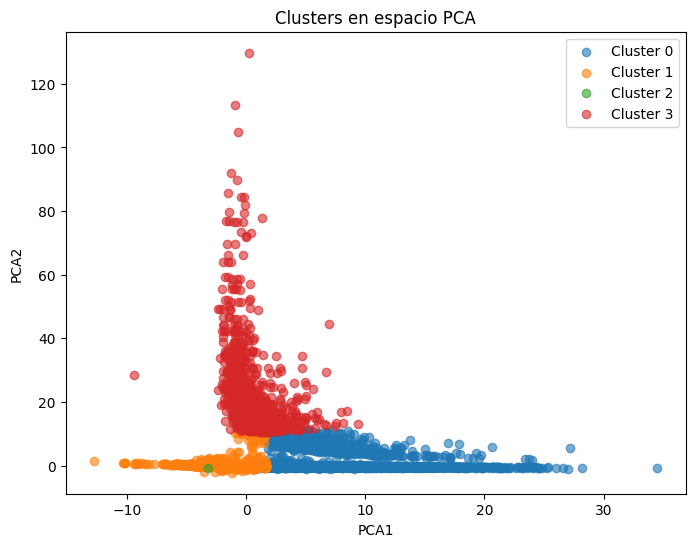

In [224]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_final['pca1'] = X_pca[:, 0]
df_final['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
for c in range(optimal_k):
    plt.scatter(df_final[df_final['cluster'] == c]['pca1'], 
                df_final[df_final['cluster'] == c]['pca2'], 
                label=f'Cluster {c}', alpha=0.6)
plt.legend()
plt.title('Clusters en espacio PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()


Análisis de los perfiles medios
Cluster 0 (azul, el núcleo)
- Usuarios promedio/bajo riesgo: baja dispersión en compras (new_purchase_std), compras máximas negativas/moderadas, pocos comercios únicos, pocas transacciones, duración media del historial de compras (~235 días), y un target promedio ligeramente positivo (0.08).

- Interpretación: Segmento base, comportamiento estable y saludable, sin riesgos ni patrones atípicos.

Cluster 1 (naranja, el segundo en tamaño)
- Usuarios muy activos y diversificados: mayor dispersión en compras y número de transacciones (new_num_transactions=13.4), muchos comercios distintos (~70), categorías distintas (~10), historial más largo (~269 días), y un target negativo (-0.36).

- Interpretación: Clientes intensivos, pero con menor score (target bajo): pueden ser grandes compradores pero menos “leales” o con mayor riesgo/variabilidad.

Cluster 4 (lila, minoritario)
- Perfil mixto/intermedio: Valores medios en compras y diversidad, target negativo pero poco pronunciado (-0.07).

- Interpretación: Grupo pequeño, de comportamiento entre los clusters 0 y 1; pueden ser un segmento de nicho o transitorio.

Cluster 2 (verde, atípico pequeño)
- Comportamiento raro/extremo: Algunos valores desproporcionados, especialmente en ventas de merchants, y target bastante bajo (-0.42).

- Interpretación: Outliers o clientes con comportamientos específicos o errores de registro.

Cluster 3 (rojo, 1 registro)
- Totalmente atípico: Todas las métricas distorsionadas (por ejemplo, hist_purchase_mean y target con valores extremadamente altos).

- Interpretación: Error, registro aislado o caso excepcional. Debería excluirse de análisis de negocio.

In [21]:
total_var = df_final['target'].var()

In [22]:
intra_var = (
    df_final.groupby('cluster').apply(lambda g: g['target'].var() * len(g))
).sum() / len(df_final)

C:\Users\Paul\AppData\Local\Temp\ipykernel_28448\2387298461.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final.groupby('cluster').apply(lambda g: g['target'].var() * len(g))


In [23]:
explained_var = 1 - intra_var / total_var
print(f"Varianza explicada por los clusters: {explained_var:.2%}")

Varianza explicada por los clusters: 1.27%


Dado que las variables transaccionales seleccionadas no muestran correlación significativa con el score de lealtad, los métodos de clustering no supervisado no logran segmentar adecuadamente el target. Para capturar relaciones complejas, es recomendable emplear modelos no lineales supervisados como LightGBM, que permiten identificar patrones e interacciones no evidentes a simple vista.

Limitaciones del Clustering Tradicional y Rol de Modelos Supervisados
Durante el análisis exploratorio y de segmentación, aplicamos técnicas de clustering no supervisado (KMeans) para agrupar clientes en función de sus patrones de compra, tanto históricos como recientes, junto a atributos agregados de los comercios. Sin embargo, al evaluar la capacidad de estos clusters para explicar la variabilidad del score de lealtad (nuestra variable objetivo), encontramos que la varianza explicada fue solo del 1.27%, muy por debajo del umbral del 80% planteado en los objetivos SMART del proyecto.

Este resultado evidencia una baja relación entre los patrones de comportamiento utilizados para el clustering y el score de lealtad. Esto puede deberse a que:

Las variables seleccionadas no capturan los verdaderos factores que determinan el score.

El score de lealtad depende de relaciones complejas, no necesariamente lineales o directamente observables en los datos disponibles.

La alta dispersión del target dentro de cada cluster indica que los grupos formados reflejan diferencias de comportamiento, pero no diferencias relevantes en el score.

Dado que los métodos de clustering clásico (KMeans, GMM, DBSCAN, etc.) no utilizan el target para formar grupos, son muy efectivos para segmentar por similitud de comportamiento, pero no garantizan que los clusters resultantes sean predictivos del target. Incluso con algoritmos de clustering más avanzados, si no existe una relación subyacente fuerte, el resultado será similar.

Por esta razón, se recomienda complementar el análisis con modelos supervisados no lineales, como LightGBM, XGBoost o Random Forest, los cuales permiten capturar relaciones complejas y no lineales entre las variables independientes y el score de lealtad. Estos modelos han demostrado ser más efectivos para la predicción y explicación del target, incluso cuando la correlación lineal es baja.

En conclusión, el clustering aporta valor para la segmentación y generación de perfiles de clientes, útil para diseñar campañas diferenciadas. Sin embargo, para explicar y predecir el score de lealtad, es indispensable utilizar modelos supervisados avanzados, que logran capturar patrones y relaciones invisibles para los métodos no supervisados.